In [ ]:
!chmod o+x /scratch/skannoji/Research/CT_Detection/KT_Files

In [ ]:
!ls -ld  /scratch/skannoji/Research/CT_Detection/KT_Files

In [ ]:
import os
import math
import requests
from concurrent.futures import ThreadPoolExecutor
import time
from tqdm import tqdm
import json
import numpy as np
from PIL import Image
from collections import defaultdict
import torch
import cv2
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, clear_output
import shutil
import yaml
import mercantile
from rasterio.transform import Affine
import rasterio

In [ ]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the root directory.")
    exit()

# --- Assign variables from the loaded config ---
# Input Paths
YOLO_MODEL_PATH = config['paths']['yolo_model']
SAM2_CHECKPOINT_PATH = config['paths']['sam2_checkpoint']

# Output Directories
STITCHED_GRID_DIR = config['dirs']['stitched_grids']
HITL_REVIEW_DIR = config['dirs']['hitl_review']
ACCEPTED_DIR = config['dirs']['accepted']
REJECTED_DIR = config['dirs']['rejected']
FINAL_MASKS_DIR = config['dirs']['final_masks']
OUTPUTS_DIR = config['dirs']['outputs']

# Output Filenames (will be joined with OUTPUTS_DIR)
FINAL_STITCHED_MASK_PNG = os.path.join(OUTPUTS_DIR, config['files']['final_stitched_mask_png'])
GRID_TILE_MAP_JSON = os.path.join(OUTPUTS_DIR, config['files']['grid_tile_map_json'])
ALL_BOX_COORDS_PKL = os.path.join(OUTPUTS_DIR, config['files']['all_box_coords_pkl'])
SELECTED_IMAGES_PKL = os.path.join(OUTPUTS_DIR, config['files']['selected_images_pkl'])

# Geographic & Tile Settings
MIN_LAT, MAX_LAT = config['geo']['min_lat'], config['geo']['max_lat']
MIN_LON, MAX_LON = config['geo']['min_lon'], config['geo']['max_lon']
ZOOM = config['geo']['zoom']
TILE_URL_TEMPLATE = config['geo']['tile_url_template']

# Processing Settings
THREADS = config['processing']['threads']
TILE_SIZE = config['processing']['tile_size']
GRID_SIZE = config['processing']['grid_size']
GRID_OUTPUT_SIZE = TILE_SIZE * GRID_SIZE

# Downloading images

In [1]:
# --- 1. Load Configuration from YAML file ---
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
# <-- All constants are now loaded from your config file
OUTPUT_DIR = config['dirs']['stitched_grids'] # Use the stitched_grids dir as the output for raw tiles
THREADS = config['processing']['threads']
TILE_SIZE = config['processing']['tile_size']
ZOOM = config['geo']['zoom']

MIN_LAT, MAX_LAT = config['geo']['min_lat'], config['geo']['max_lat']
MIN_LON, MAX_LON = config['geo']['min_lon'], config['geo']['max_lon']

TILE_URL_TEMPLATE = config['geo']['tile_url_template']

# For simplicity, we'll create the error log in the output directory
ERROR_LOG_FILE = os.path.join(config['dirs']['outputs'], "download_error_log.txt")

# --- Helper Functions (No changes needed here) ---

def deg_to_tile(lat, lon, zoom):
    """Convert latitude and longitude to tile coordinates for Web Mercator."""
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y


def download_tile(x, y, z):
    """Download a tile and save it locally."""
    url = TILE_URL_TEMPLATE.format(z=z, x=x, y=y)
    output_path = os.path.join(OUTPUT_DIR, f"tile_{z}_{x}_{y}.jpeg")

    # This function uses the globally defined variables loaded from config
    # No need to check for existence if we are deleting the folder each time,
    # but good practice to keep it.
    if os.path.exists(output_path):
        return

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(output_path, "wb") as f:
                f.write(response.content)
            return True
    except Exception as e:
        pass # Fail silently for tqdm
    
    with open(ERROR_LOG_FILE, "a") as log_file:
        log_file.write(f"Failed: {z}/{x}/{y}\n")
    return False


def main():
    # Create output directories
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(config['dirs']['outputs'], exist_ok=True)


    # Determine tile range
    min_x, min_y = deg_to_tile(MAX_LAT, MIN_LON, ZOOM)
    max_x, max_y = deg_to_tile(MIN_LAT, MAX_LON, ZOOM)

    print(f"Tile range: X ({min_x} to {max_x}), Y ({min_y} to {max_y})")

    # --- BUG FIX: Removed hardcoded 'zoom = 13' ---
    # The 'tiles' list now correctly uses the ZOOM variable (21) from config.
    tiles = [(x, y, ZOOM) for x in range(min_x, max_x + 1)
             for y in range(min_y, max_y + 1)]
    
    print(f"Total tiles to download: {len(tiles)}")
    
    # Download tiles using ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=THREADS) as executor:
        list(tqdm(executor.map(lambda t: download_tile(*t), tiles), total=len(tiles)))

    print("Download complete!")

if __name__ == "__main__":
    main()

Tile range: X (396495 to 396620), Y (841730 to 841856)
min_x: 396495, max_x: 396620, min_y: 841730, max_y: 841856
16002


100%|██████████| 16002/16002 [02:04<00:00, 128.80it/s]

Download complete!


# Stitching to PNG

In [3]:
# === Configuration ===
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
# Note: The TILE_DIR should point to where the raw tiles from the previous step were saved.
# I'll assume the config has a 'raw_tiles' entry for this.
TILE_DIR = config['dirs'].get('raw_tiles', config['dirs']['stitched_grids']) # Fallback for your original config
OUTPUT_GRID_DIR = config['dirs']['stitched_grids']
OUTPUTS_DIR = config['dirs']['outputs']

# Construct full paths for output files
FINAL_PNG = os.path.join(OUTPUTS_DIR, config['files']['final_stitched_grids_png']) # Assuming this is a new entry in your config
GRID_MAP_JSON = os.path.join(OUTPUTS_DIR, config['files']['grid_tile_map_json'])

# Processing settings
ZOOM = config['geo']['zoom']
TILE_SIZE = config['processing']['tile_size']
GRID_SIZE = config['processing']['grid_size']
GRID_OUTPUT_SIZE = TILE_SIZE * GRID_SIZE

# --- Main Script Logic (largely unchanged) ---

os.makedirs(OUTPUT_GRID_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# === Parse all available tile filenames
tile_files = {
    (int(f.split("_")[2]), int(f.split("_")[3].split(".")[0])): f
    for f in os.listdir(TILE_DIR)
    if f.startswith(f"tile_{ZOOM}_") and f.endswith(".jpeg")
}

tile_coords = set(tile_files.keys())

# === Determine tile grid boundaries
if not tile_coords:
    print(f"Error: No tile files found in {TILE_DIR}. Please run the download cell first.")
else:
    x_vals = sorted(set(x for x, _ in tile_coords))
    y_vals = sorted(set(y for _, y in tile_coords))

    # === Determine usable grid ranges (must be divisible by GRID_SIZE)
    usable_x = x_vals[:len(x_vals) - (len(x_vals) % GRID_SIZE)]
    usable_y = y_vals[:len(y_vals) - (len(y_vals) % GRID_SIZE)]

    grid_map = {}
    grid_images = []

    print(f"🔧 Stitching {GRID_SIZE}x{GRID_SIZE} tile grids (non-overlapping)...")
    for gx in tqdm(range(0, len(usable_x), GRID_SIZE)):
        for gy in range(0, len(usable_y), GRID_SIZE):
            x_block = usable_x[gx:gx+GRID_SIZE]
            y_block = usable_y[gy:gy+GRID_SIZE]

            if len(x_block) < GRID_SIZE or len(y_block) < GRID_SIZE:
                continue

            all_coords = [(x, y) for y in y_block for x in x_block]
            if all(coord in tile_coords for coord in all_coords):
                grid_img = np.zeros((GRID_OUTPUT_SIZE, GRID_OUTPUT_SIZE, 3), dtype=np.uint8)
                used_files = []

                for idx, (x, y) in enumerate(all_coords):
                    row = idx // GRID_SIZE
                    col = idx % GRID_SIZE
                    fname = tile_files[(x, y)]
                    tile_img = Image.open(os.path.join(TILE_DIR, fname)).convert("RGB")
                    grid_img[row*TILE_SIZE:(row+1)*TILE_SIZE,
                             col*TILE_SIZE:(col+1)*TILE_SIZE, :] = np.array(tile_img)
                    used_files.append(fname)

                grid_index = f"grid_{x_block[0]}_{y_block[0]}"
                grid_path = os.path.join(OUTPUT_GRID_DIR, f"{grid_index}.png")
                Image.fromarray(grid_img).save(grid_path)
                grid_images.append(grid_img)
                grid_map[grid_index] = used_files

    # === Save mapping
    with open(GRID_MAP_JSON, "w") as f:
        json.dump(grid_map, f, indent=2)

    # === Stitch all grids into one final image
    if grid_images:
        indexed_images = []
        for grid_index, img in zip(grid_map.keys(), grid_images):
            parts = grid_index.split("_")
            x, y = int(parts[1]), int(parts[2])
            indexed_images.append(((x, y), img))

        grid_dict = defaultdict(dict)
        for (x, y), img in indexed_images:
            grid_dict[y][x] = img

        sorted_rows = sorted(grid_dict.keys())
        x_coords_all = sorted(set(x for y in sorted_rows for x in grid_dict[y]))
        num_cols = len(x_coords_all)
        num_rows = len(sorted_rows)

        final_image = np.zeros((num_rows * GRID_OUTPUT_SIZE, num_cols * GRID_OUTPUT_SIZE, 3), dtype=np.uint8)

        print(f"🧩 Stitching {len(grid_images)} grids into final image...")
        for row_idx, y in enumerate(sorted_rows):
            x_in_row = sorted(grid_dict[y].keys())
            for col_idx, x in enumerate(x_in_row):
                img = grid_dict[y][x]
                final_image[row_idx * GRID_OUTPUT_SIZE:(row_idx + 1) * GRID_OUTPUT_SIZE,
                            col_idx * GRID_OUTPUT_SIZE:(col_idx + 1) * GRID_OUTPUT_SIZE, :] = img

        Image.fromarray(final_image).save(FINAL_PNG)
        print(f"✅ Final spatially correct stitched PNG saved: {FINAL_PNG}")
        print(f"📦 Tile mapping saved: {GRID_MAP_JSON}")
    else:
        print("No complete grids were found to stitch.")

🔧 Stitching 3x3 tile grids (non-overlapping)...


100%|██████████| 42/42 [11:22<00:00, 16.24s/it]


🧩 Stitching 3x3 grids row-by-row...
✅ Final spatially correct stitched PNG saved: tempe_stitched_all_3x3_grids.png
📦 Tile mapping saved: grid_tile_map.json


# Changing to TIFF

In [1]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
OUTPUTS_DIR = config['dirs']['outputs']

# Construct full paths for input/output files
# NOTE: You may need to add 'final_stitched_grids_png' and 'final_geotiff' to your config.yaml
INPUT_PNG = os.path.join(OUTPUTS_DIR, config['files'].get('final_stitched_grids_png', 'tempe_stitched_all_3x3_grids.png'))
GRID_MAP_JSON = os.path.join(OUTPUTS_DIR, config['files']['grid_tile_map_json'])
OUTPUT_TIF = os.path.join(OUTPUTS_DIR, config['files'].get('final_geotiff', 'tempe_stitched_final_rgb_georef.tif'))


# Processing settings
ZOOM = config['geo']['zoom']
TILE_SIZE = config['processing']['tile_size']
GRID_SIZE = config['processing']['grid_size']

# --- Main Script Logic (largely unchanged) ---

# Allow Pillow to handle very large images
Image.MAX_IMAGE_PIXELS = None

try:
    # === Load RGB image and mapping
    print(f"Loading stitched PNG: {INPUT_PNG}")
    img = Image.open(INPUT_PNG).convert("RGB")
    rgb_arr = np.array(img)  # shape: (H, W, 3)

    print(f"Loading grid map: {GRID_MAP_JSON}")
    with open(GRID_MAP_JSON, "r") as f:
        grid_map = json.load(f)
except FileNotFoundError as e:
    print(f"Error: A required input file was not found. {e}")
    print("Please ensure the previous cells have been run successfully.")
else:
    # === Get top-left and bottom-right tile coords from grid keys
    grid_keys = sorted(grid_map.keys(), key=lambda k: (
        int(k.split("_")[2]),  # y-coordinate for sorting rows
        int(k.split("_")[1])   # x-coordinate for sorting columns
    ))

    top_left_key = grid_keys[0]
    bottom_right_key = grid_keys[-1]

    x0 = int(top_left_key.split("_")[1])
    y0 = int(top_left_key.split("_")[2])
    # The bottom-right corner of the final grid tile is GRID_SIZE-1 tiles away
    x1 = int(bottom_right_key.split("_")[1]) + (GRID_SIZE - 1)
    y1 = int(bottom_right_key.split("_")[2]) + (GRID_SIZE - 1)

    # === Compute Web Mercator bounds for the entire stitched image
    top_left_bounds = mercantile.xy_bounds(mercantile.Tile(x0, y0, ZOOM))
    bottom_right_bounds = mercantile.xy_bounds(mercantile.Tile(x1, y1, ZOOM))

    minx = top_left_bounds.left
    maxy = top_left_bounds.top
    maxx = bottom_right_bounds.right
    miny = bottom_right_bounds.bottom

    # === Compute the affine transformation matrix
    height, width = rgb_arr.shape[:2]
    res_x = (maxx - minx) / width
    res_y = (maxy - miny) / height
    transform = Affine(res_x, 0, minx, 0, -res_y, maxy)

    # === Write the final RGB GeoTIFF
    print(f"Writing georeferenced TIFF to: {OUTPUT_TIF}")
    with rasterio.open(OUTPUT_TIF, 'w', driver='GTiff',
                       height=height, width=width,
                       count=3, dtype='uint8',
                       crs='EPSG:3857',
                       transform=transform) as dst:
        # Write each color channel (R, G, B) separately
        for i in range(3):
            dst.write(rgb_arr[:, :, i], i + 1)

    print(f"✅ RGB GeoTIFF saved successfully!")


KeyboardInterrupt: 

In [ ]:
print('Done')

# SAM model loading 

In [2]:
import re
import os
import time
import json
import random
from PIL import Image
import matplotlib.pyplot as plt
import sys
import numpy as np
import torch
import cv2
import os
import pickle
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from concurrent.futures import ThreadPoolExecutor

from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
from torchvision.ops.boxes import batched_nms, box_area  # type: ignore

# from sam2.modeling.sam2_base import SAM2Base
from sam2.sam2_image_predictor import SAM2ImagePredictor
from ultralytics import YOLO
from tqdm import tqdm

In [ ]:
# --- 1. Load Configuration from YAML file ---
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
# This path should be relative to your project root in the config file
SAM2_CHECKPOINT_PATH = config['paths']['sam2_checkpoint']

# NOTE: The sam2 library and its config files should be part of your project.
# We will assume a 'sam2' folder exists at the project root.
SAM2_CONFIG_FILE = "sam2/configs/sam2.1/sam2.1_hiera_b+.yaml"


# --- Main Script Logic ---

# It's good practice to ensure the necessary libraries are available.
# This assumes the 'sam2' library is in a folder named 'sam2' at the project root.
try:
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor
except ImportError:
    print("Error: The 'sam2' library could not be imported.")
    print("Please ensure the 'segment-anything-2' repository is cloned as 'sam2' in your project root.")
    exit()


print(f"Loading SAM2 model checkpoint from: {SAM2_CHECKPOINT_PATH}")
if not os.path.isfile(SAM2_CHECKPOINT_PATH):
    print(f"Error: SAM2 checkpoint not found at the specified path.")
    exit()

# Use bfloat16 for memory-efficient processing on CUDA devices
if torch.cuda.is_available():
    torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()
    print("CUDA available. Using bfloat16 for autocasting.")


# Load the SAM2 model using the paths from our config
sam2_model = build_sam2(SAM2_CONFIG_FILE, SAM2_CHECKPOINT_PATH, device="cuda")

# Create the predictor object which will be used in the next steps
sam_predictor = SAM2ImagePredictor(sam2_model)

print("\n✅ SAM2 model and predictor loaded successfully!")


In [15]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    exit()

# --- 2. Assign Variables from Config ---
YOLO_MODEL_PATH = config['paths']['yolo_model']
IMAGE_DIRECTORY = config['dirs']['stitched_grids']
OUTPUTS_DIR = config['dirs']['outputs']
ALL_BOX_COORDS_PKL = os.path.join(OUTPUTS_DIR, config['files']['all_box_coords_pkl'])
THREADS = config['processing']['threads']

# --- Helper Function ---
def process_image(image_path, yolo_model):
    """
    Processes a single image using the pre-loaded YOLO model.
    Returns detection data if objects are found, otherwise None.
    """
    try:
        # Run YOLO inference
        results = yolo_model.predict(source=image_path, conf=0.3, imgsz=768, augment=True, verbose=False)
        
        if len(results[0].boxes.xyxy) > 0:
            # Return path, boxes, and confidence scores if detections are found
            return (image_path, results[0].boxes.xyxy, results[0].boxes.conf)
    except Exception as e:
        print(f"Error processing {os.path.basename(image_path)}: {e}")
    
    return None

# --- Main Execution ---
def main():
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUTS_DIR, exist_ok=True)

    print("--- Starting YOLO Detection Stage ---")
    start_time = time.time()

    # --- 3. Load YOLO Model Once ---
    # This is more efficient than loading it inside the loop for every image.
    print(f"Loading YOLO model from: {YOLO_MODEL_PATH}")
    yolo = YOLO(YOLO_MODEL_PATH)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    yolo.to(device)
    print(f"Model loaded on device: {device}")

    # Get a list of all image paths to process
    try:
        image_paths = [os.path.join(IMAGE_DIRECTORY, f) for f in os.listdir(IMAGE_DIRECTORY) if f.endswith(".png")]
        if not image_paths:
            print(f"Warning: No PNG files found in {IMAGE_DIRECTORY}")
            return
    except FileNotFoundError:
        print(f"Error: Image directory not found at {IMAGE_DIRECTORY}")
        return

    print(f"Found {len(image_paths)} total images to process.")

    all_box_coords_and_images = []

    # Use partial to pass the loaded yolo model to the process_image function
    process_func = partial(process_image, yolo_model=yolo)

    with ThreadPoolExecutor(max_workers=THREADS) as executor:
        # The map function will apply `process_func` to each `image_path`
        results = list(tqdm(executor.map(process_func, image_paths), total=len(image_paths), desc="Processing Images"))

    # Filter out the None results from images with no detections
    all_box_coords_and_images = [res for res in results if res is not None]
    
    total_detections = sum(len(boxes) for _, boxes, _ in all_box_coords_and_images)

    # --- 4. Save Results ---
    print(f"\nDetection complete. Found {total_detections} total objects in {len(all_box_coords_and_images)} grids.")
    with open(ALL_BOX_COORDS_PKL, "wb") as f:
        pickle.dump(all_box_coords_and_images, f)
    print(f"Results saved to: {ALL_BOX_COORDS_PKL}")

    execution_time = time.time() - start_time
    print(f"Total time taken: {execution_time:.2f} seconds.")

if __name__ == "__main__":
    main()

Total images:  1764


Processing Images: 100%|██████████| 1764/1764 [06:32<00:00,  4.49it/s]

Total time taken to run the code: 393.19 seconds.


# Images saving for review

In [16]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
OUTPUTS_DIR = config['dirs']['outputs']
ALL_BOX_COORDS_PKL = os.path.join(OUTPUTS_DIR, config['files']['all_box_coords_pkl'])
REVIEW_DIR = config['dirs']['hitl_review']
CONF_THRESHOLD = config['hitl']['confidence_threshold']


# --- Main Script Logic (largely unchanged) ---

# --- Image Drawing Function ---
def draw_boxes_on_image(img_path, boxes, confs, save_path):
    """Draws bounding boxes on an image and saves it."""
    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not read image {img_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image_rgb)
    ax.axis('off')

    # Draw bounding boxes
    for box, conf in zip(boxes, confs):
        if conf >= CONF_THRESHOLD:
            x1, y1, x2, y2 = map(int, box)
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 10, f'{conf:.2f}', color='white', fontsize=10,
                    bbox=dict(facecolor='lime', alpha=0.5, pad=0))

    # Save the figure to the specified path
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

# --- Main Processing Loop ---
try:
    with open(ALL_BOX_COORDS_PKL, "rb") as f:
        all_data = pickle.load(f)
except FileNotFoundError:
    print(f"Error: Detection data not found at {ALL_BOX_COORDS_PKL}")
    print("Please run the YOLO detection cell first.")
else:
    os.makedirs(REVIEW_DIR, exist_ok=True)
    print(f"Preparing images for review. Saving to: {REVIEW_DIR}")
    
    for img_path, boxes, confs in tqdm(all_data, desc="Drawing boxes on grids"):
        # We only need to prepare images that have at least one box above the threshold
        if any(c >= CONF_THRESHOLD for c in confs):
            filename = os.path.basename(img_path)
            save_path = os.path.join(REVIEW_DIR, filename)
            draw_boxes_on_image(img_path, boxes.cpu().numpy(), confs.cpu().numpy(), save_path)

    print("✅ Preparation complete.")


Preparing images for review. Saving to: /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/retrain_model/tempe_hitl_review_grids


Drawing boxes on grids:   0%|          | 0/56 [00:00<?, ?it/s]

✅ Preparation complete.


# Adding to accepted folder 

In [1]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
REVIEW_DIR = config['dirs']['hitl_review']
SAVE_DIR_YES = config['dirs']['accepted']
SAVE_DIR_NO = config['dirs']['rejected']
OUTPUTS_DIR = config['dirs']['outputs']
SELECTED_IMAGES_PKL = os.path.join(OUTPUTS_DIR, config['files']['selected_images_pkl'])

# --- Main Script Logic (largely unchanged) ---

os.makedirs(SAVE_DIR_YES, exist_ok=True)
os.makedirs(SAVE_DIR_NO, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)


# This list will hold the filenames of the grids you accept
selected_images = []

# Get the list of prepared grid images for review
try:
    image_list = sorted([f for f in os.listdir(REVIEW_DIR) if f.endswith(".png")])
    if not image_list:
        print(f"Warning: No review images found in {REVIEW_DIR}. Please run the preparation cell first.")
except FileNotFoundError:
    print(f"Error: Review directory not found at {REVIEW_DIR}")
    image_list = []

img_idx = 0
out = widgets.Output()
nav_buttons_box = widgets.HBox([]) # Placeholder for buttons

# --- Functions for the Interface ---
def handle_decision(decision):
    global img_idx
    if img_idx < len(image_list):
        img_filename = image_list[img_idx]
        source_path = os.path.join(REVIEW_DIR, img_filename)
        
        if decision == 'yes':
            # Add the original filename to our list and copy the file
            selected_images.append(img_filename)
            shutil.copy2(source_path, os.path.join(SAVE_DIR_YES, img_filename))
        elif decision == 'no':
            shutil.copy2(source_path, os.path.join(SAVE_DIR_NO, img_filename))
        
        # Move to the next image
        img_idx += 1
        display_next_image()

def display_next_image():
    with out:
        clear_output(wait=True)
        if image_list and img_idx < len(image_list):
            print(f"Showing image {img_idx + 1}/{len(image_list)}")
            img_path = os.path.join(REVIEW_DIR, image_list[img_idx])
            display(Image(filename=img_path, width=600))
        else:
            print("✅ Done with all images.")
            print(f"Total images selected: {len(selected_images)}")
            # Disable buttons and save the final list
            for button in nav_buttons_box.children:
                button.disabled = True
            save_selected_list()

def save_selected_list():
    """Saves the list of accepted filenames to a pickle file."""
    with open(SELECTED_IMAGES_PKL, 'wb') as f:
        pickle.dump(selected_images, f)
    print(f"\n✅ Saved {len(selected_images)} selected grid filenames to '{SELECTED_IMAGES_PKL}'")
    print("This file is now ready for your SAM model script.")

# --- Button Widgets and Callbacks ---
button_yes = widgets.Button(description="✔ Accept", button_style='success')
button_no = widgets.Button(description="✘ Reject", button_style='danger')
button_skip = widgets.Button(description="➡ Skip", button_style='info')

button_yes.on_click(lambda b: handle_decision('yes'))
button_no.on_click(lambda b: handle_decision('no'))
button_skip.on_click(lambda b: handle_decision('skip'))

nav_buttons_box.children = [button_yes, button_no, button_skip]

# --- Start the review process ---
if image_list:
    display(nav_buttons_box, out)
    display_next_image()
else:
    print("No images to review.")


Output()

In [4]:
def display_next_image():
    with out:
        clear_output(wait=True)
        if image_list and img_idx < len(image_list):
            # ... displays the image
        else:
            print("✅ Done with all images.")
            # ... disables buttons
            save_selected_list() # <-- SAVES YOUR FILE HERE

✅ Saved 25 selected grid filenames to 'new_tempe_selected_images.pkl'
This file is now ready for your SAM model script.

Sample of selected files:
['grid_396495_841730.png', 'grid_396498_841730.png', 'grid_396510_841775.png', 'grid_396513_841730.png', 'grid_396513_841772.png', 'grid_396513_841808.png', 'grid_396513_841811.png', 'grid_396513_841814.png', 'grid_396516_841736.png', 'grid_396516_841739.png']


# Running SAM on whole PNG 

In [10]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    exit()

# --- 2. Assign Variables from Config ---
GRID_DIR = config['dirs']['stitched_grids']
MASK_DIR = config['dirs']['final_masks']
OUTPUTS_DIR = config['dirs']['outputs']

# Input files
ALL_BOX_COORDS_PKL = os.path.join(OUTPUTS_DIR, config['files']['all_box_coords_pkl'])
SELECTED_IMAGES_PKL = os.path.join(OUTPUTS_DIR, config['files']['selected_images_pkl'])
FINETUNED_SAM_CHECKPOINT = config['paths']['sam2_finetuned_checkpoint']

# Processing settings
MASK_SIZE = config['processing'].get('mask_size', 768) # Use .get for flexibility

# --- Helper Function ---
def expand_box(x1, y1, x2, y2, image_shape, padding=0.25, fixed_padding=50):
    """ Expands a bounding box by a given percentage and fixed padding. """
    height, width = image_shape[:2]
    box_width = x2 - x1
    box_height = y2 - y1
    x1 = max(0, x1 - int(box_width * padding) - fixed_padding)
    y1 = max(0, y1 - int(box_height * padding) - fixed_padding)
    x2 = min(width, x2 + int(box_width * padding) + fixed_padding)
    y2 = min(height, y2 + int(box_height * padding) + fixed_padding)
    return x1, y1, x2, y2

# --- Main Script Logic ---
def main():
    os.makedirs(MASK_DIR, exist_ok=True)

    # --- 3. Load Data ---
    try:
        with open(ALL_BOX_COORDS_PKL, "rb") as f:
            all_data = pickle.load(f)
        with open(SELECTED_IMAGES_PKL, "rb") as f:
            selected_images = pickle.load(f)
    except FileNotFoundError as e:
        print(f"Error: Required data file not found. {e}")
        print("Please ensure the previous cells have run successfully.")
        return

    yolo_final_results = set(selected_images)
    print(f"Found {len(yolo_final_results)} human-verified grids to process.")

    # Create a lookup dictionary for the verified detections
    detections = {
        os.path.basename(path): (path, boxes.cpu().numpy())
        for path, boxes, _ in all_data
        if os.path.basename(path) in yolo_final_results
    }

    # --- 4. Load Fine-Tuned SAM2 Model ---
    # This assumes `sam_predictor` object was created in the previous cell
    # and we are now loading the fine-tuned weights into it.
    try:
        print(f"Loading fine-tuned SAM weights from: {FINETUNED_SAM_CHECKPOINT}")
        sam_predictor.model.load_state_dict(torch.load(FINETUNED_SAM_CHECKPOINT)['model'])
    except (NameError, FileNotFoundError):
        print("Error: `sam_predictor` object not found or checkpoint path is invalid.")
        print("Please ensure the SAM model loading cell was run and config.yaml is correct.")
        return

    # --- 5. Run Segmentation on Verified Grids ---
    print("🧠 Running SAM on YOLO-confirmed grids...")
    
    # More efficient: Iterate directly over the verified detections
    for fname, (img_path, boxes) in tqdm(detections.items(), desc="Generating Masks"):
        out_path = os.path.join(MASK_DIR, fname)
        
        try:
            full_mask = np.zeros((MASK_SIZE, MASK_SIZE), dtype=np.uint8)
            image_rgb = np.array(Image.open(img_path).convert("RGB"))

            for box in boxes:
                x1, y1, x2, y2 = map(int, box)
                ex1, ey1, ex2, ey2 = expand_box(x1, y1, x2, y2, image_rgb.shape)

                if ex2 <= ex1 or ey2 <= ey1:
                    continue

                region = image_rgb[ey1:ey2, ex1:ex2]

                # Run SAM prediction on the cropped region
                sam_predictor.set_image(region)
                input_box = np.array([[0, 0, region.shape[1], region.shape[0]]])
                masks, _, _ = sam_predictor.predict(box=input_box, multimask_output=True)

                # Combine all generated masks for this region
                for mask in masks:
                    resized = cv2.resize(mask.astype(np.uint8), (ex2 - ex1, ey2 - ey1), interpolation=cv2.INTER_NEAREST)
                    full_mask[ey1:ey2, ex1:ex2] |= resized

            # Save the final combined mask for the grid
            Image.fromarray((full_mask > 0).astype(np.uint8) * 255).save(out_path)

        except Exception as e:
            print(f"💥 Error processing {fname}: {e}")
            continue

    print(f"\n✅ All masks for accepted grids have been saved to: {MASK_DIR}")

if __name__ == "__main__":
    # This check allows the script to be run from the command line if needed
    main()


Found 25 human-verified grids to process.
🧠 Running SAM on YOLO-confirmed grids...


100%|██████████| 1764/1764 [00:36<00:00, 48.38it/s] 

All masks written to: /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/tempe_masks


# Radius Calculation

In [10]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    exit()

# --- 2. Assign Variables from Config ---
GRID_DIR = config['dirs']['stitched_grids']
ACCEPTED_DIR = config['dirs']['accepted']
MASK_DIR = config['dirs']['final_masks']
OUTPUTS_DIR = config['dirs']['outputs']

# Input files
ALL_BOX_COORDS_PKL = os.path.join(OUTPUTS_DIR, config['files']['all_box_coords_pkl'])
FINETUNED_SAM_CHECKPOINT = config['paths']['sam2_finetuned_checkpoint']

# Processing settings
MASK_SIZE = config['processing'].get('mask_size', 768)

# --- Helper Function ---
def expand_box(x1, y1, x2, y2, image_shape, padding=0.25, fixed_padding=50):
    """ Expands a bounding box by a given percentage and fixed padding. """
    height, width = image_shape[:2]
    box_width = x2 - x1
    box_height = y2 - y1
    x1 = max(0, x1 - int(box_width * padding) - fixed_padding)
    y1 = max(0, y1 - int(box_height * padding) - fixed_padding)
    x2 = min(width, x2 + int(box_width * padding) + fixed_padding)
    y2 = min(height, y2 + int(box_height * padding) + fixed_padding)
    return x1, y1, x2, y2

# --- Main Script Logic ---
def main():
    os.makedirs(MASK_DIR, exist_ok=True)

    # --- 3. Load Data ---
    try:
        with open(ALL_BOX_COORDS_PKL, "rb") as f:
            all_data = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: Detections file not found at {ALL_BOX_COORDS_PKL}. Please run YOLO detection first.")
        return

    # Create a lookup map for bounding boxes: filename -> boxes_tensor
    detections_map = {
        os.path.basename(path): boxes.cpu().numpy()
        for path, boxes, _ in all_data
    }

    # Get the list of accepted filenames DIRECTLY from the folder
    try:
        print(f"Reading accepted files from: {ACCEPTED_DIR}")
        accepted_files = [f for f in os.listdir(ACCEPTED_DIR) if f.endswith(".png")]
        print(f"Found {len(accepted_files)} human-verified grids to process.")
        if not accepted_files:
            print("No accepted files found. Exiting.")
            return
    except FileNotFoundError:
        print(f"Error: Accepted directory not found at {ACCEPTED_DIR}. Please run the HITL step.")
        return

    # --- 4. Load Fine-Tuned SAM2 Model ---
    # This assumes `sam_predictor` object was created in a previous cell
    try:
        print(f"Loading fine-tuned SAM weights from: {FINETUNED_SAM_CHECKPOINT}")
        sam_predictor.model.load_state_dict(torch.load(FINETUNED_SAM_CHECKPOINT)['model'])
    except (NameError, FileNotFoundError):
        print("Error: `sam_predictor` object not found or checkpoint path is invalid.")
        print("Please ensure the SAM model loading cell was run and config.yaml is correct.")
        return

    # --- 5. Run Segmentation on Verified Grids ---
    print("🧠 Running SAM on human-verified grids...")
    
    for fname in tqdm(accepted_files, desc="Generating Masks"):
        img_path = os.path.join(GRID_DIR, fname)
        out_path = os.path.join(MASK_DIR, fname)
        
        if not os.path.exists(img_path) or fname not in detections_map:
            print(f"⚠️ Warning: Skipping {fname} as its original grid or box data was not found.")
            continue

        try:
            full_mask = np.zeros((MASK_SIZE, MASK_SIZE), dtype=np.uint8)
            image_rgb = np.array(Image.open(img_path).convert("RGB"))
            boxes = detections_map[fname]

            for box in boxes:
                x1, y1, x2, y2 = map(int, box)
                ex1, ey1, ex2, ey2 = expand_box(x1, y1, x2, y2, image_rgb.shape)

                if ex2 <= ex1 or ey2 <= ey1:
                    continue

                region = image_rgb[ey1:ey2, ex1:ex2]

                # Run SAM prediction on the cropped region
                sam_predictor.set_image(region)
                input_box = np.array([[0, 0, region.shape[1], region.shape[0]]])
                masks, _, _ = sam_predictor.predict(box=input_box, multimask_output=True)

                # Combine all generated masks for this region
                for mask in masks:
                    resized = cv2.resize(mask.astype(np.uint8), (ex2 - ex1, ey2 - ey1), interpolation=cv2.INTER_NEAREST)
                    full_mask[ey1:ey2, ex1:ex2] |= resized

            # Save the final combined mask for the grid
            Image.fromarray((full_mask > 0).astype(np.uint8) * 255).save(out_path)

        except Exception as e:
            print(f"💥 Error processing {fname}: {e}")
            continue

    print(f"\n✅ All masks for accepted grids have been saved to: {MASK_DIR}")

if __name__ == "__main__":
    # This check allows the script to be run from the command line if needed
    main()


Reading accepted files from: /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/new_accepted_grids
Found 25 human-verified grids to process.
🧠 Running SAM on human-verified grids...


 12%|█▏        | 3/25 [00:00<00:04,  5.06it/s]

⚠️ Warning: Skipping grid_396582_841823.png as its original grid or box data was not found.


 20%|██        | 5/25 [00:00<00:02,  6.75it/s]

⚠️ Warning: Skipping grid_396594_841781.png as its original grid or box data was not found.


100%|██████████| 25/25 [00:08<00:00,  2.96it/s]


✅ All masks for accepted grids have been saved to: /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/tempe_masks_accepted_only


Found 23 masks to process in /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/tempe_masks_accepted_only
Processed grid_396495_841730.png: Found 1 contours.


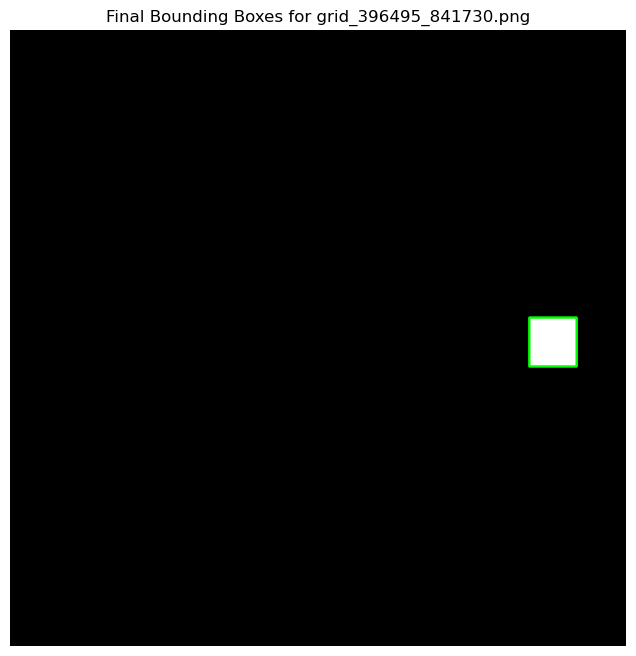

Processed grid_396522_841733.png: Found 2 contours.


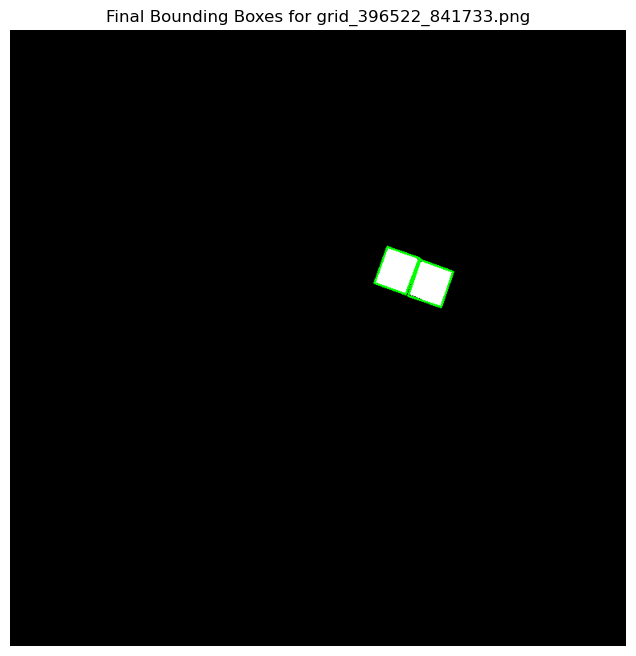

Processed grid_396510_841775.png: Found 7 contours.


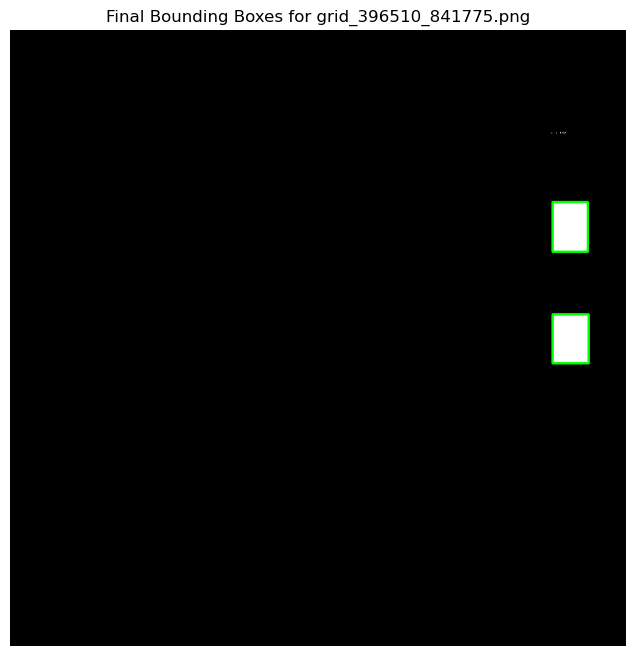

Processed grid_396555_841784.png: Found 4 contours.


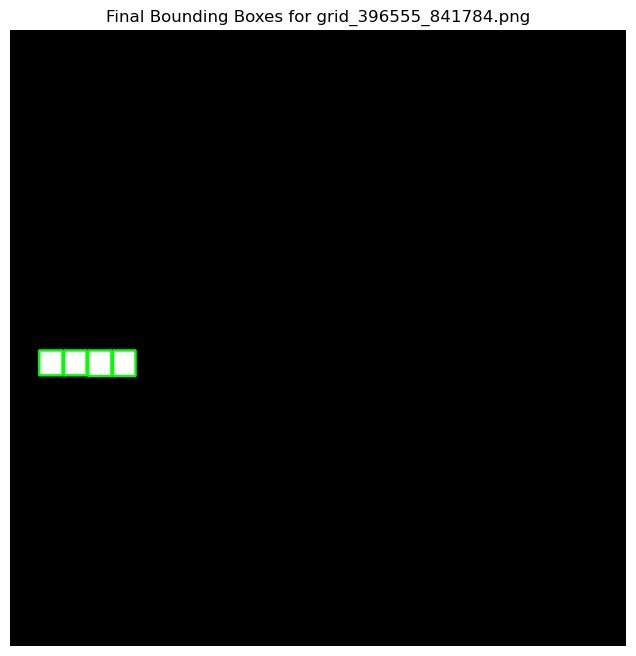

Processed grid_396513_841814.png: Found 12 contours.


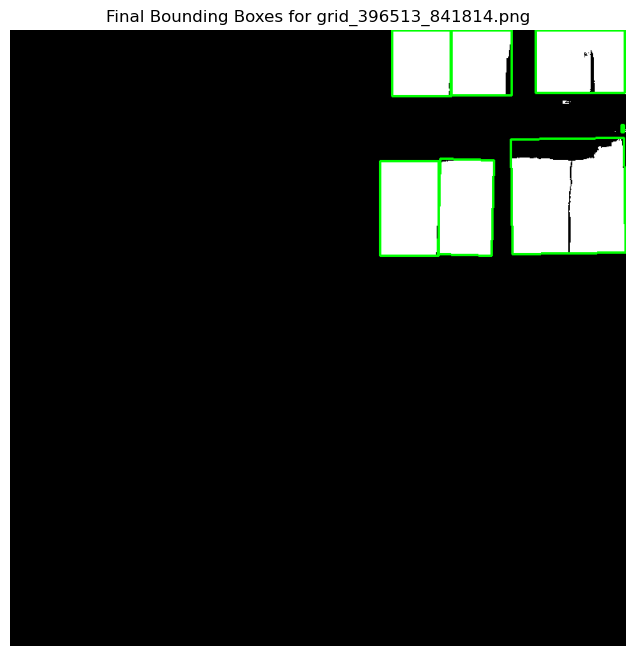

Processed grid_396513_841772.png: Found 3 contours.


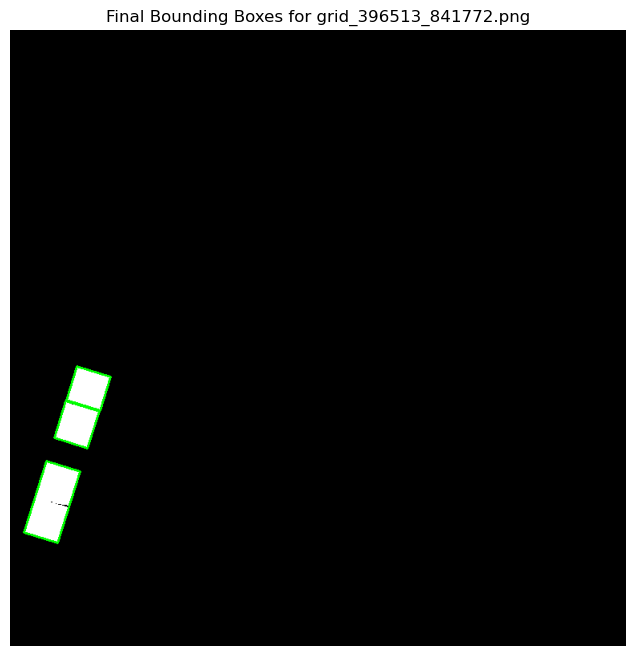

Processed grid_396531_841736.png: Found 50 contours.


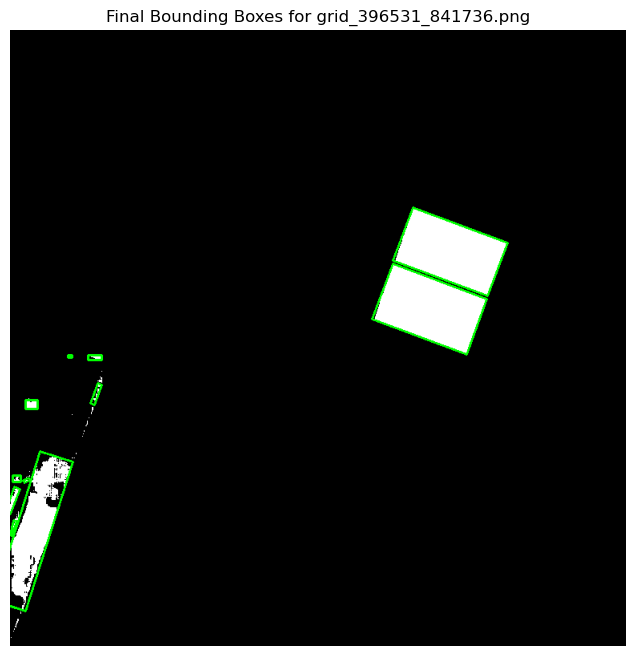

Processed grid_396543_841826.png: Found 3 contours.


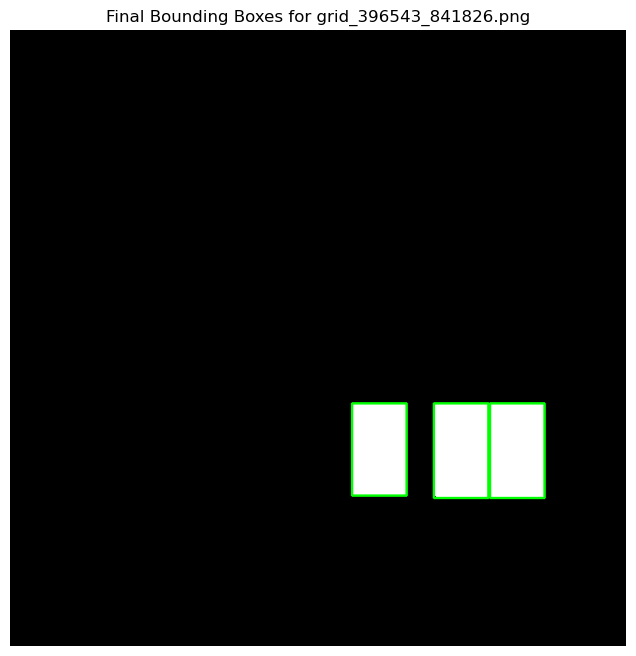

Processed grid_396516_841754.png: Found 3 contours.


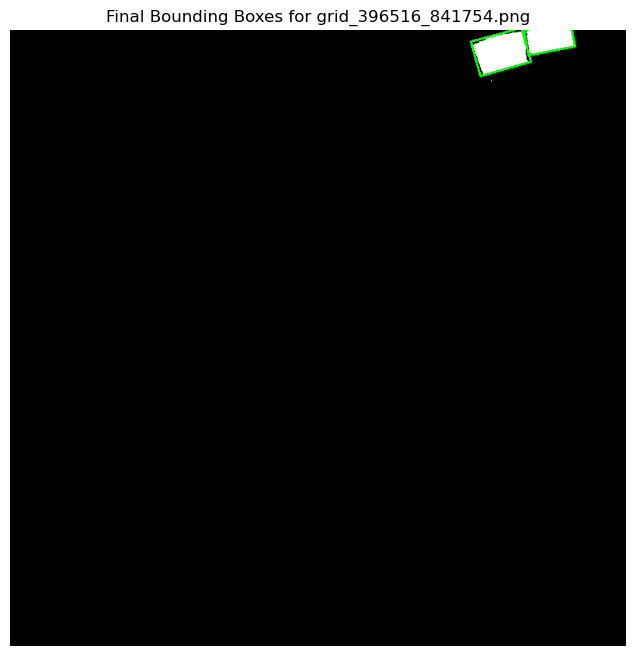

Processed grid_396585_841781.png: Found 1 contours.


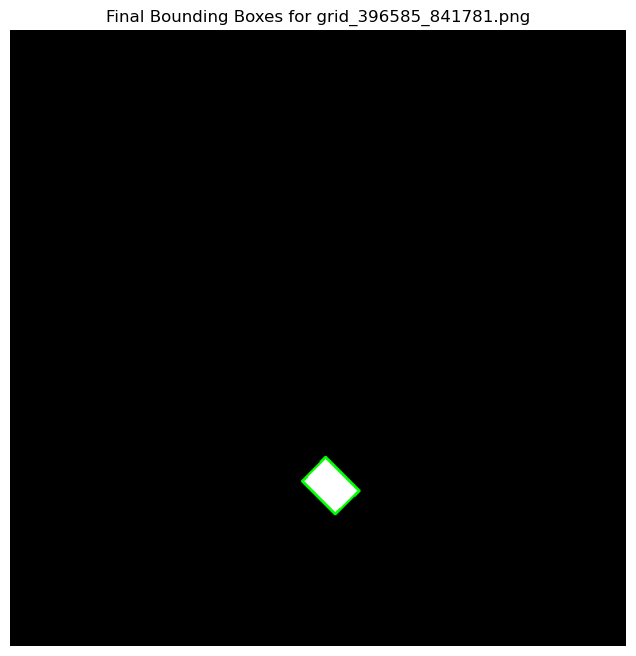

Processed grid_396513_841811.png: Found 2 contours.


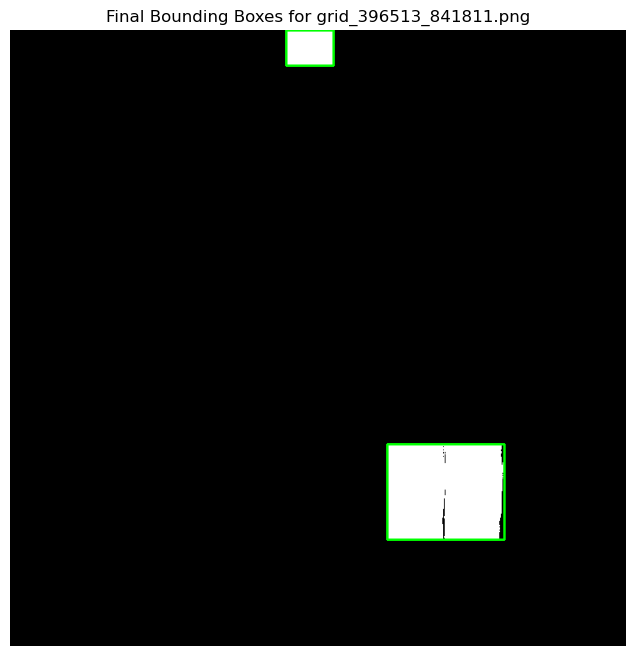

Processed grid_396543_841829.png: Found 15 contours.


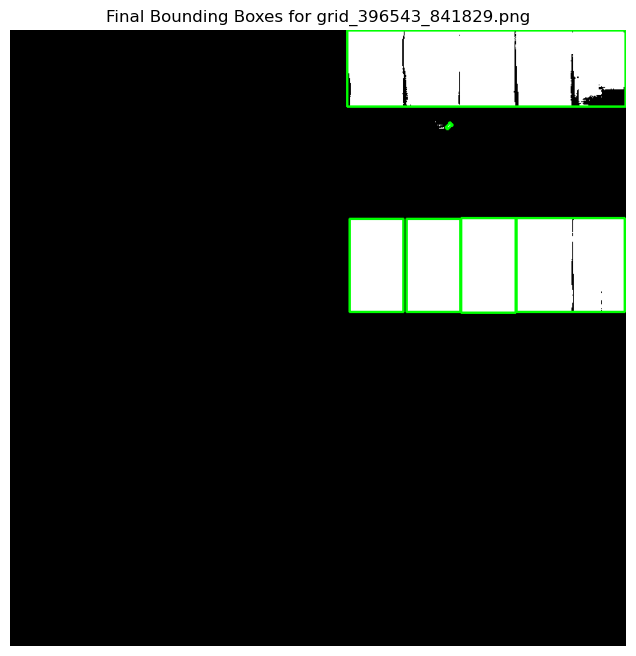

Processed grid_396516_841739.png: Found 1 contours.


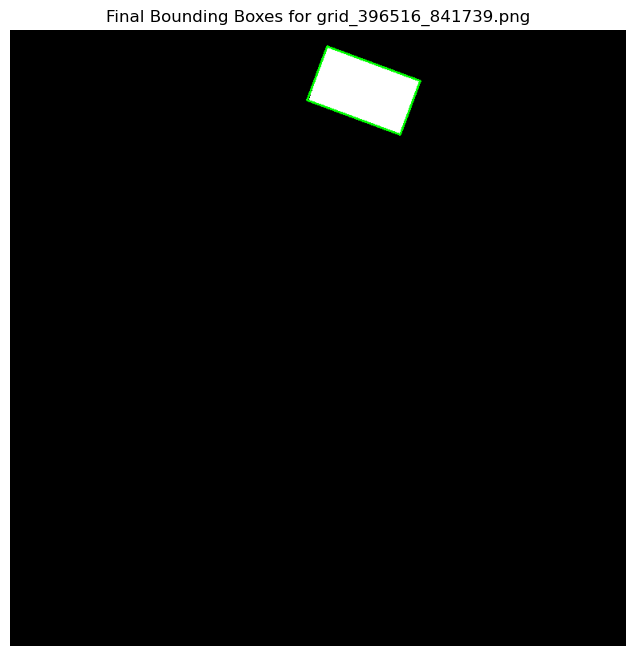

Processed grid_396549_841808.png: Found 5 contours.


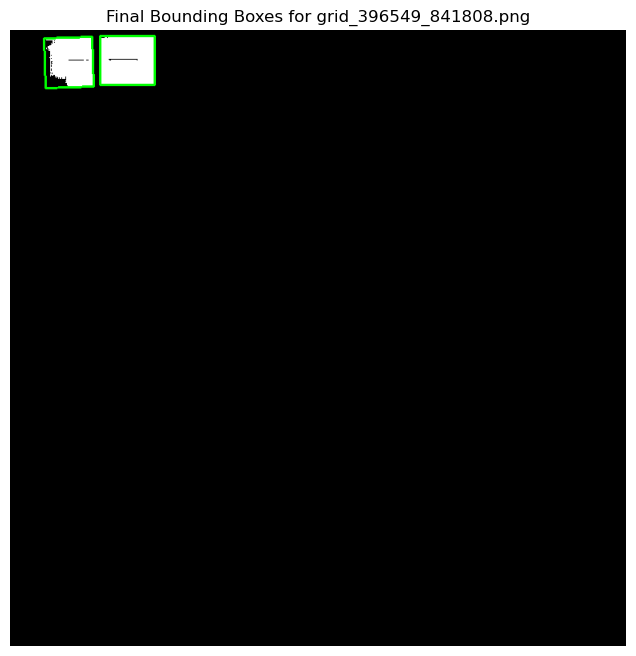

Processed grid_396516_841811.png: Found 9 contours.


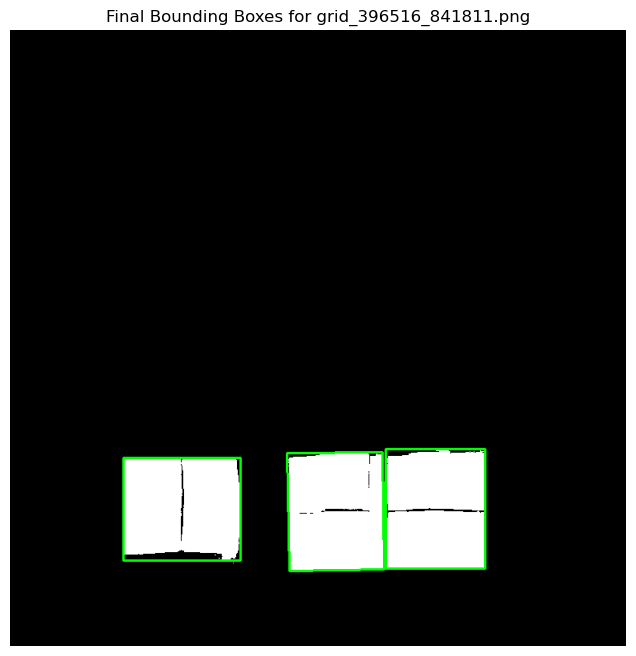

Processed grid_396528_841739.png: Found 2 contours.


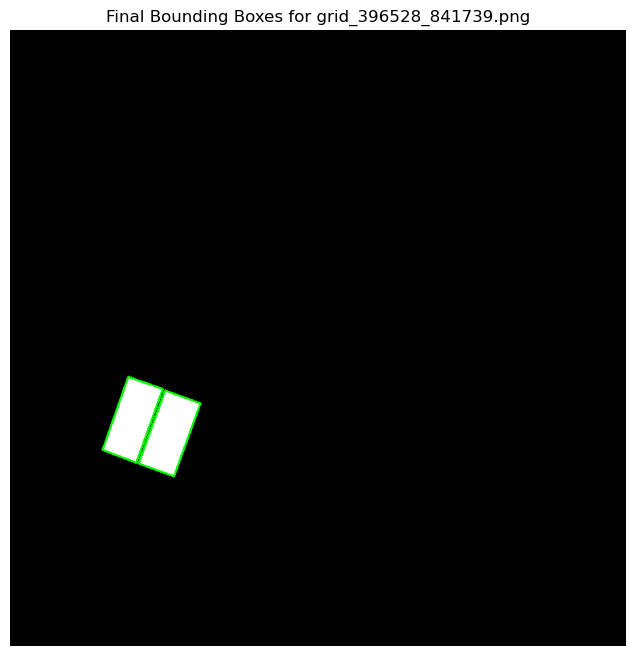

Processed grid_396513_841808.png: Found 1 contours.


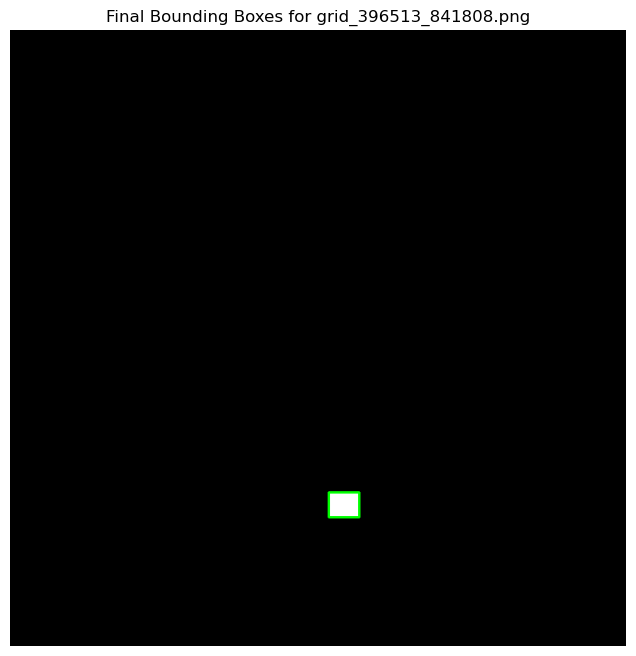

Processed grid_396573_841814.png: Found 1 contours.


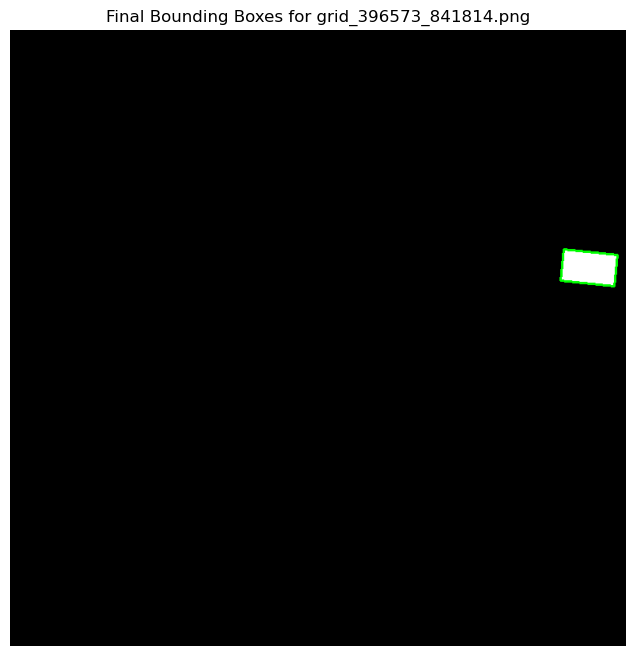

Processed grid_396525_841781.png: Found 5 contours.


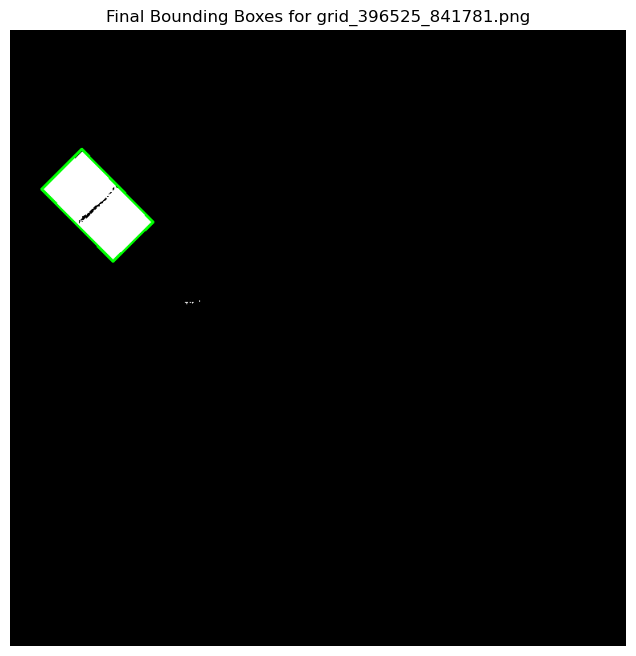

Processed grid_396498_841730.png: Found 1 contours.


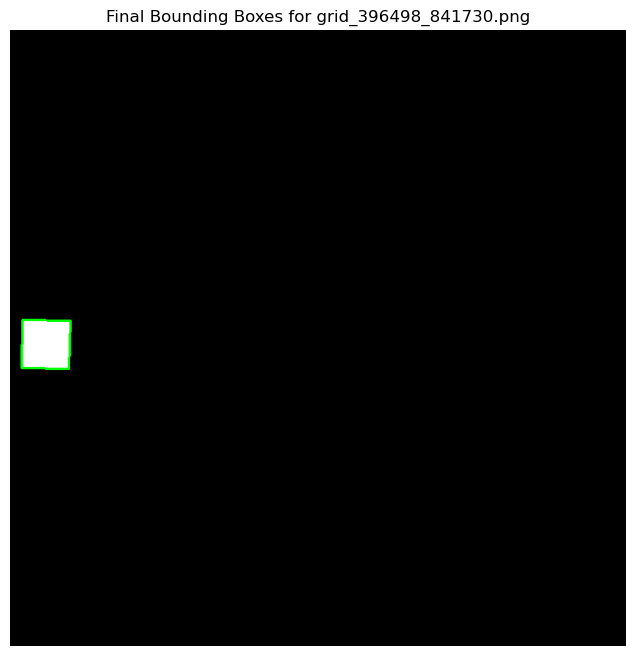

Processed grid_396513_841730.png: Found 4 contours.


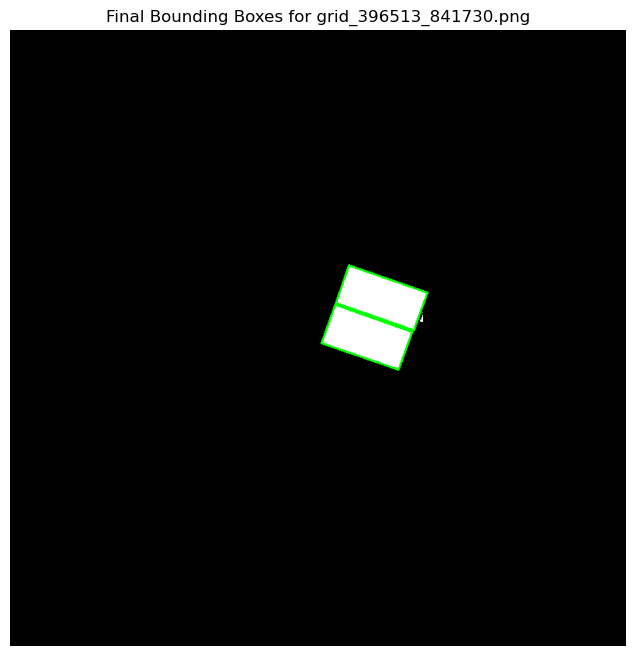

Processed grid_396543_841757.png: Found 1 contours.


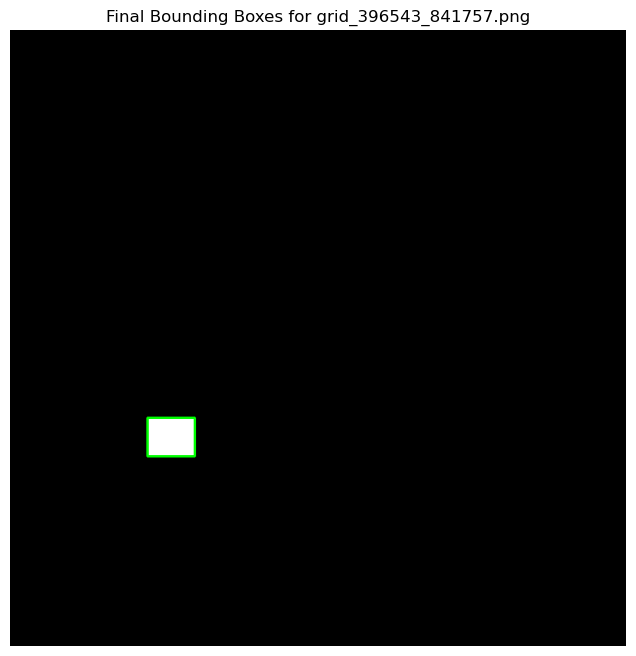

Processed grid_396516_841736.png: Found 6 contours.


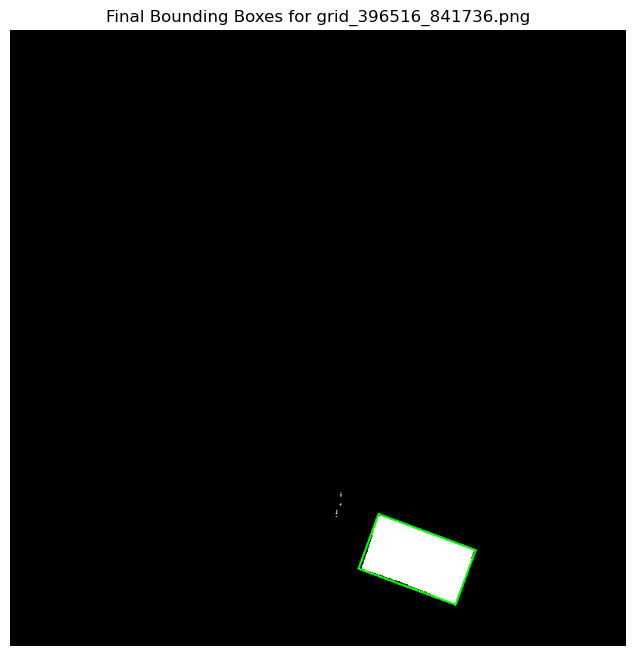


✅ All masks have been processed.


In [11]:
# === Configuration ===
# The directory where your final, human-verified masks are stored.
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
MASK_DIR = config['dirs']['final_masks']

# --- Main Script Logic ---

# Get the list of all mask files to process
try:
    mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith(".png")]
    if not mask_files:
        print(f"Warning: No mask files found in {MASK_DIR}. Please run the SAM masking cell first.")
    else:
        print(f"Found {len(mask_files)} masks to process in {MASK_DIR}")
except FileNotFoundError:
    print(f"Error: The directory '{MASK_DIR}' was not found. Please ensure the path is correct.")
    mask_files = []

# Loop through each mask file, find contours, and draw bounding boxes.
for fname in mask_files:
    mask_path = os.path.join(MASK_DIR, fname)
    mask = np.array(Image.open(mask_path).convert("L"))

    # Binarize mask to ensure it's a simple black and white image
    binary_mask = (mask > 0).astype(np.uint8)

    # Find contours of all distinct white shapes in the mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a color image from the grayscale mask to draw green boxes on
    vis_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    # Process each contour found
    for cnt in contours:
        # Skip very small contours that are likely noise
        if cv2.contourArea(cnt) < 10:
            continue

        # Get the minimum area rotated rectangle that encloses the contour
        rect = cv2.minAreaRect(cnt)

        # Get the 4 corner points of the rotated rectangle
        box = cv2.boxPoints(rect)
        box = np.intp(box)  # Convert corner points to integers

        # Draw the contour's bounding box on our visualization image
        cv2.drawContours(vis_img, [box], 0, (0, 255, 0), 2)  # Draw a green box

    # --- Display the result for the current mask ---
    print(f"Processed {fname}: Found {len(contours)} contours.")
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Final Bounding Boxes for {fname}")
    plt.axis("off")
    plt.show()

if mask_files:
    print("\n✅ All masks have been processed.")


✅ Found 23 masks to process in /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/tempe_masks_accepted_only
--------------------------------------------------
Processed grid_396495_841730.png → Found 1 shapes
  Shortest side lengths (cm): [413.0]
  Longest side lengths  (cm): [427.0]


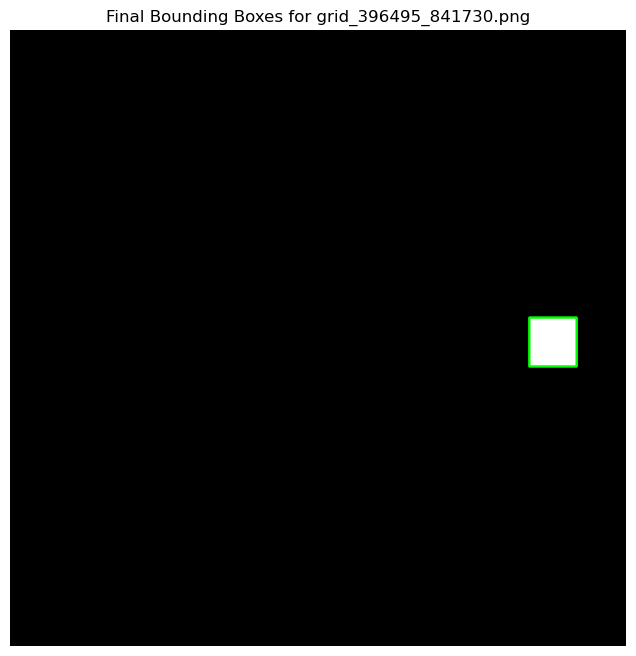

--------------------------------------------------
Processed grid_396498_841730.png → Found 1 shapes
  Shortest side lengths (cm): [417.85]
  Longest side lengths  (cm): [420.06]


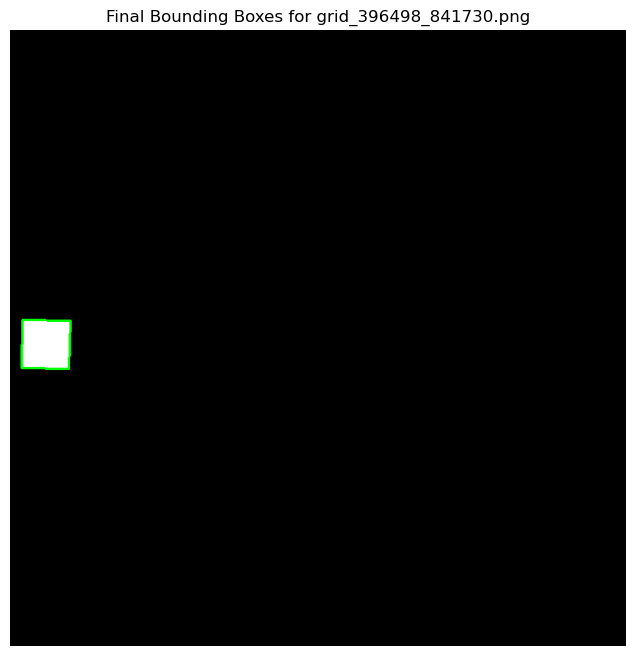

--------------------------------------------------
Processed grid_396510_841775.png → Found 2 shapes
  Shortest side lengths (cm): [315.0, 308.0]
  Longest side lengths  (cm): [427.0, 434.0]


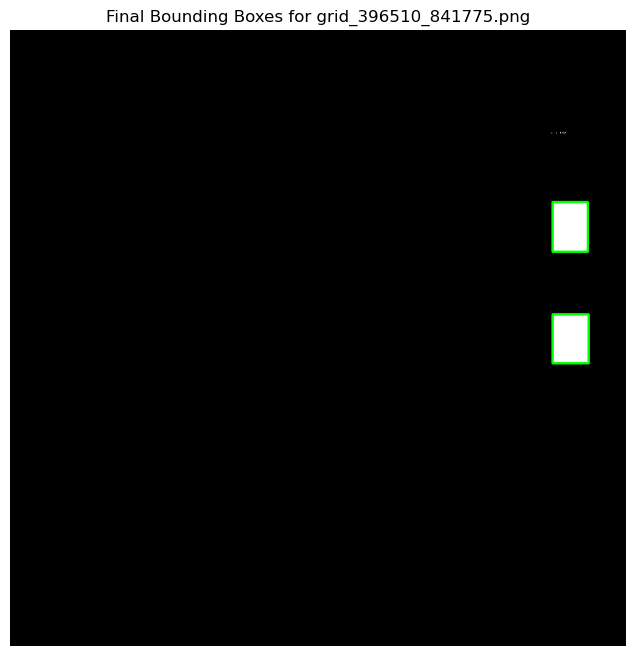

--------------------------------------------------
Processed grid_396513_841730.png → Found 2 shapes
  Shortest side lengths (cm): [352.81, 349.46]
  Longest side lengths  (cm): [707.94, 722.22]


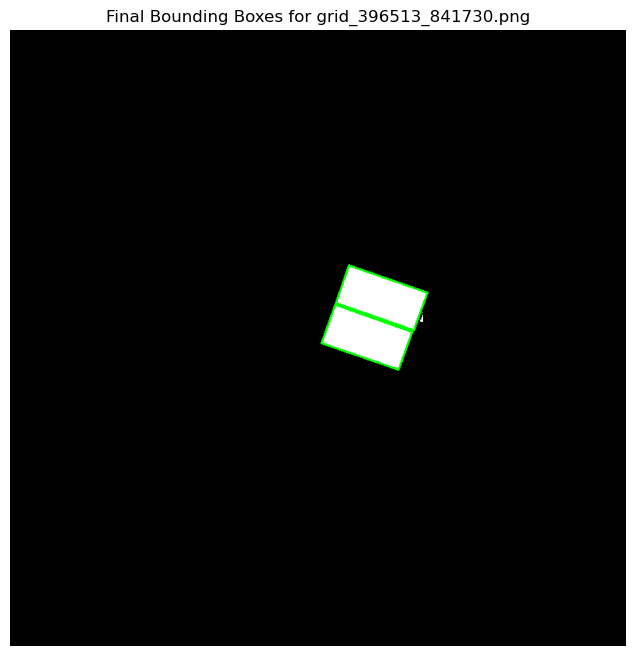

--------------------------------------------------
Processed grid_396513_841772.png → Found 3 shapes
  Shortest side lengths (cm): [308.28, 304.0, 303.89]
  Longest side lengths  (cm): [651.79, 336.57, 304.95]


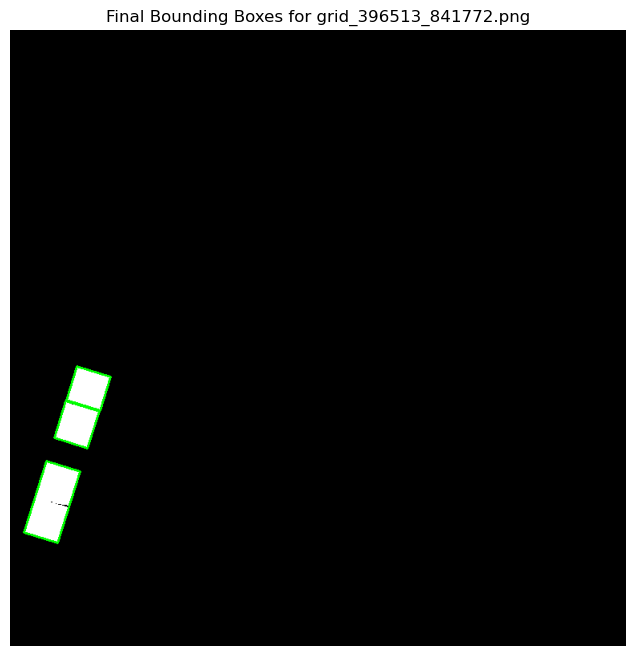

--------------------------------------------------
Processed grid_396513_841808.png → Found 1 shapes
  Shortest side lengths (cm): [217.0]
  Longest side lengths  (cm): [266.0]


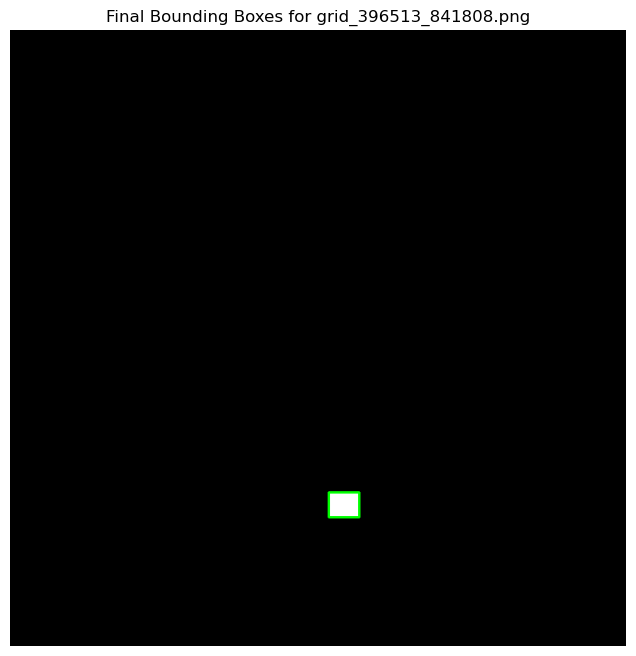

--------------------------------------------------
Processed grid_396513_841811.png → Found 2 shapes
  Shortest side lengths (cm): [833.0, 315.0]
  Longest side lengths  (cm): [1022.0, 413.0]


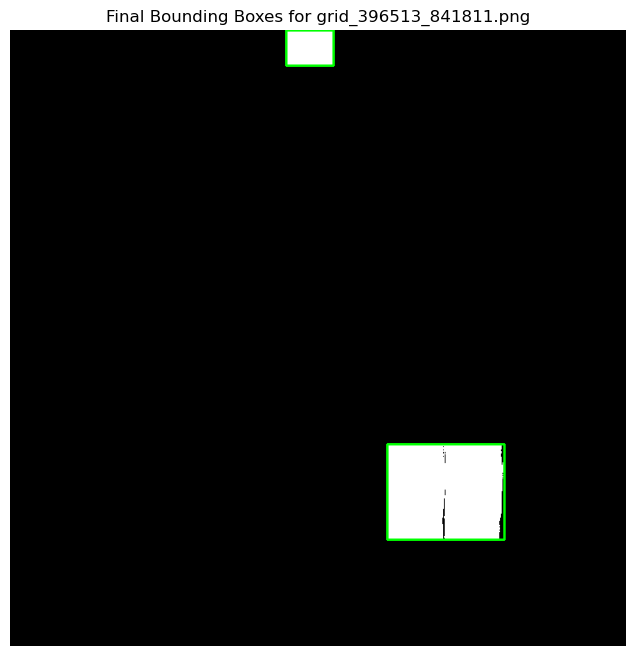

--------------------------------------------------
Processed grid_396513_841814.png → Found 7 shapes
  Shortest side lengths (cm): [511.0, 473.98, 982.9, 21.0, 553.0, 532.0, 518.0]
  Longest side lengths  (cm): [826.0, 837.02, 1001.45, 63.0, 777.0, 567.0, 574.0]


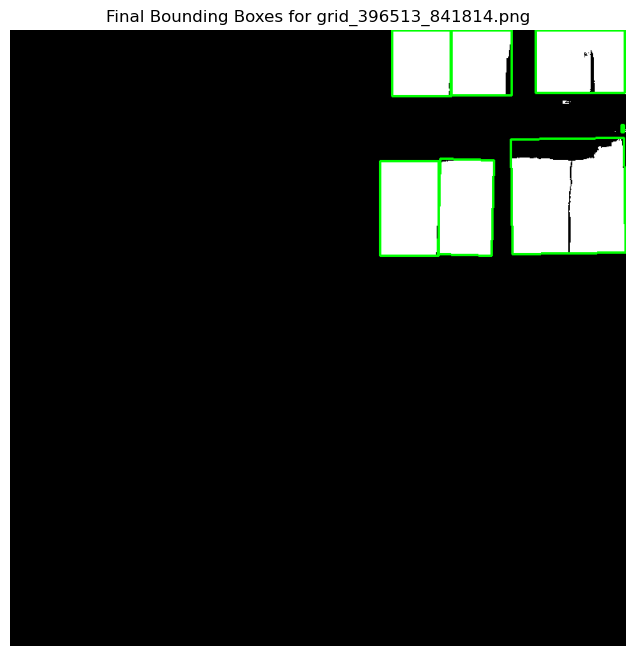

--------------------------------------------------
Processed grid_396516_841736.png → Found 1 shapes
  Shortest side lengths (cm): [507.87]
  Longest side lengths  (cm): [904.22]


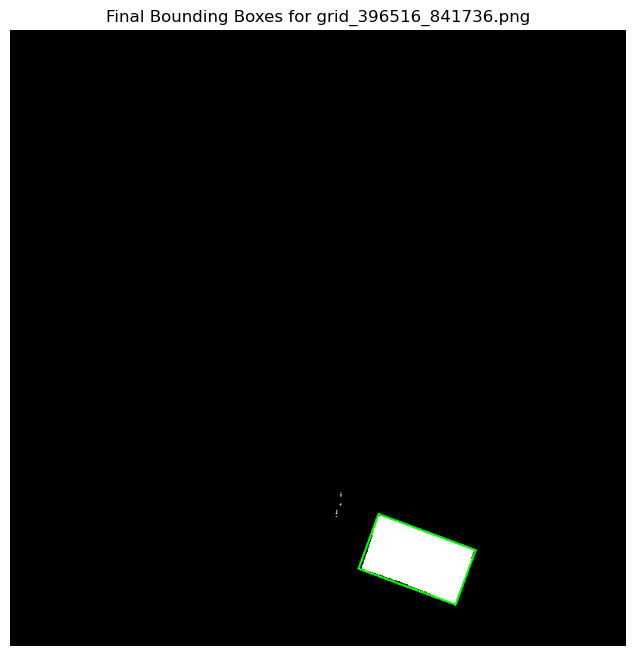

--------------------------------------------------
Processed grid_396516_841739.png → Found 1 shapes
  Shortest side lengths (cm): [502.15]
  Longest side lengths  (cm): [866.28]


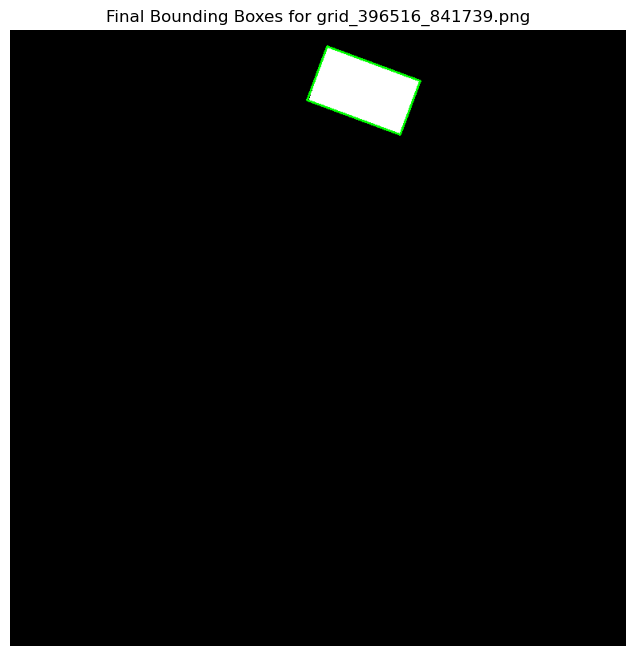

--------------------------------------------------
Processed grid_396516_841754.png → Found 2 shapes
  Shortest side lengths (cm): [311.98, 222.37]
  Longest side lengths  (cm): [456.92, 411.05]


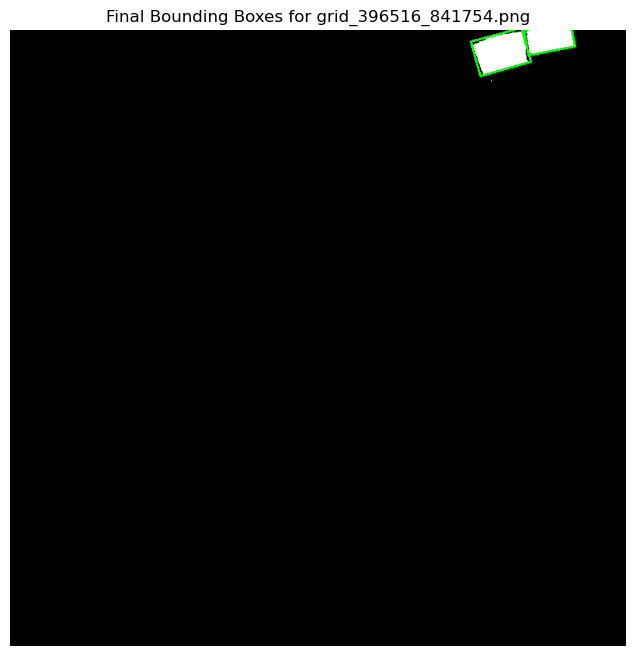

--------------------------------------------------
Processed grid_396516_841811.png → Found 3 shapes
  Shortest side lengths (cm): [896.0, 827.66, 868.0]
  Longest side lengths  (cm): [1022.0, 1025.18, 1043.0]


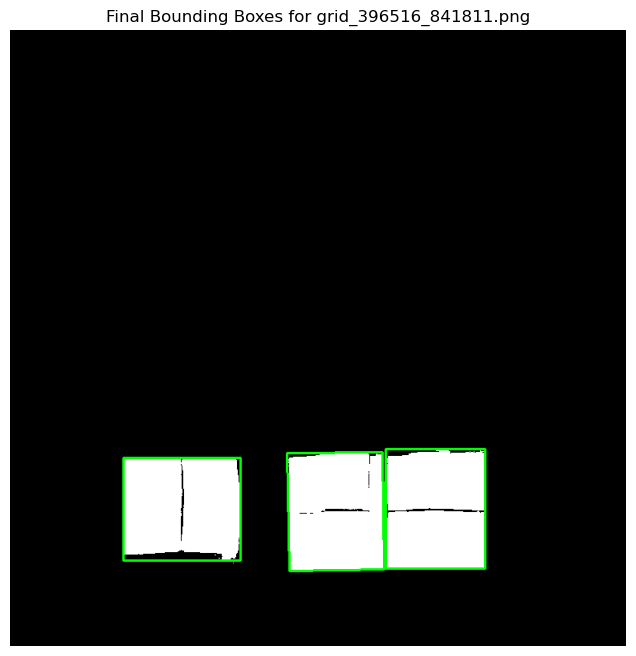

--------------------------------------------------
Processed grid_396522_841733.png → Found 2 shapes
  Shortest side lengths (cm): [304.03, 294.8]
  Longest side lengths  (cm): [327.72, 336.95]


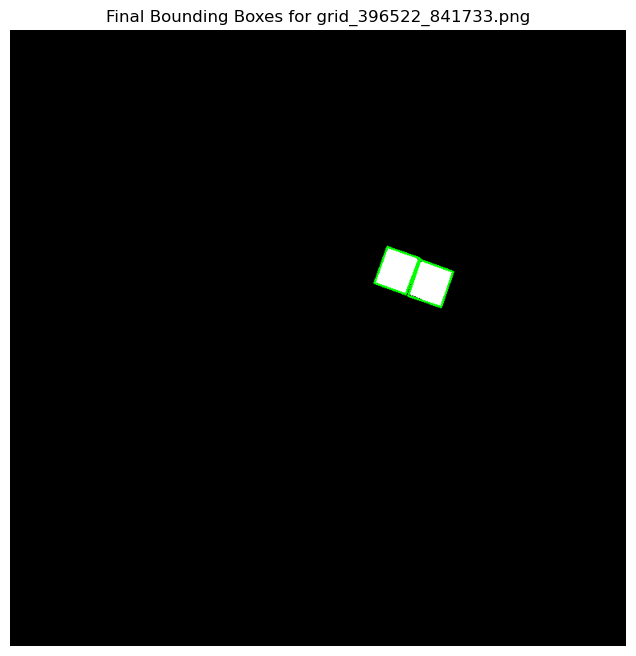

--------------------------------------------------
Processed grid_396525_841781.png → Found 1 shapes
  Shortest side lengths (cm): [491.4]
  Longest side lengths  (cm): [892.07]


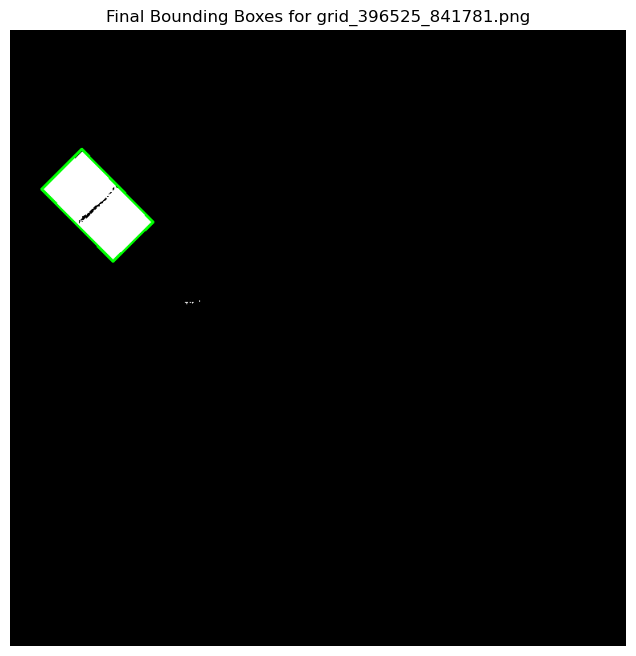

--------------------------------------------------
Processed grid_396528_841739.png → Found 2 shapes
  Shortest side lengths (cm): [325.33, 318.51]
  Longest side lengths  (cm): [678.1, 677.33]


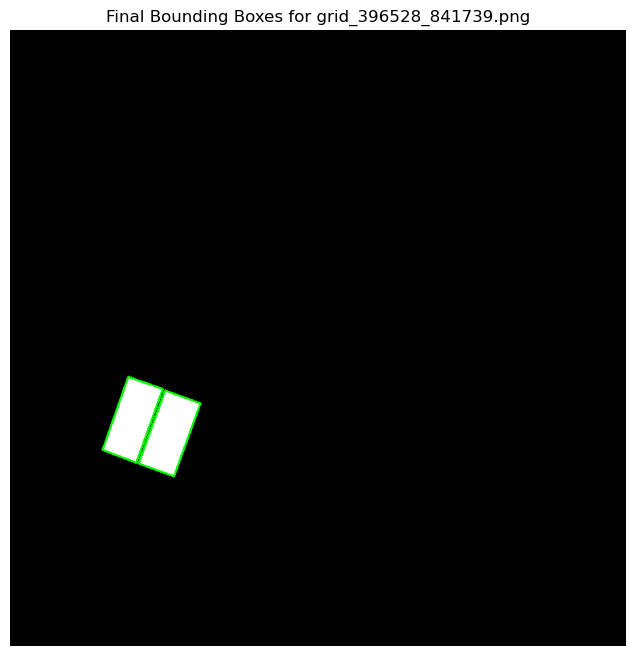

--------------------------------------------------
Processed grid_396531_841736.png → Found 11 shapes
  Shortest side lengths (cm): [24.89, 51.83, 28.17, 56.0, 302.35, 77.0, 36.11, 42.0, 21.0, 513.92, 493.21]
  Longest side lengths  (cm): [132.73, 232.35, 50.09, 70.0, 1364.83, 105.0, 185.99, 119.0, 35.0, 876.9, 881.55]


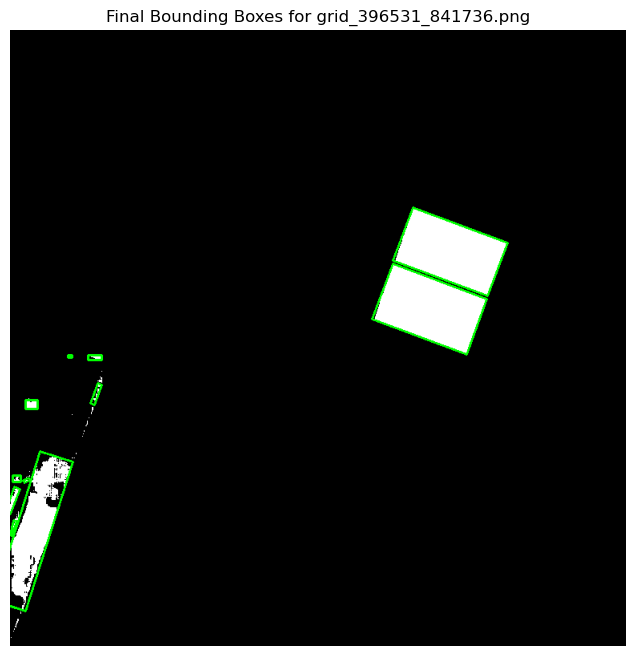

--------------------------------------------------
Processed grid_396543_841757.png → Found 1 shapes
  Shortest side lengths (cm): [336.0]
  Longest side lengths  (cm): [413.0]


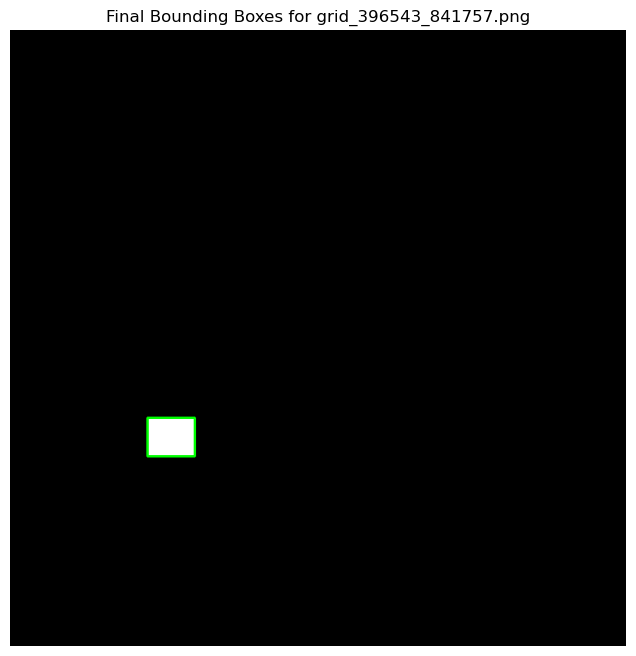

--------------------------------------------------
Processed grid_396543_841826.png → Found 3 shapes
  Shortest side lengths (cm): [476.0, 476.0, 476.0]
  Longest side lengths  (cm): [826.0, 826.0, 805.0]


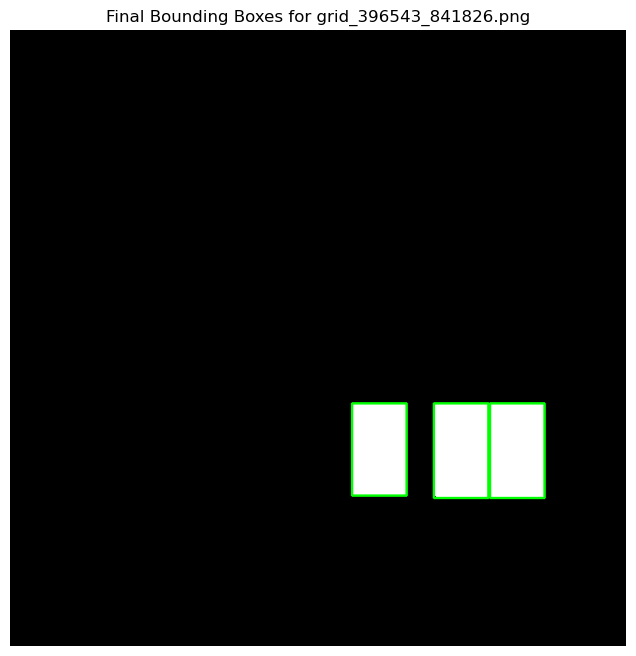

--------------------------------------------------
Processed grid_396543_841829.png → Found 6 shapes
  Shortest side lengths (cm): [469.0, 469.0, 819.0, 476.0, 24.75, 672.0]
  Longest side lengths  (cm): [812.0, 812.0, 945.0, 826.0, 54.45, 2429.0]


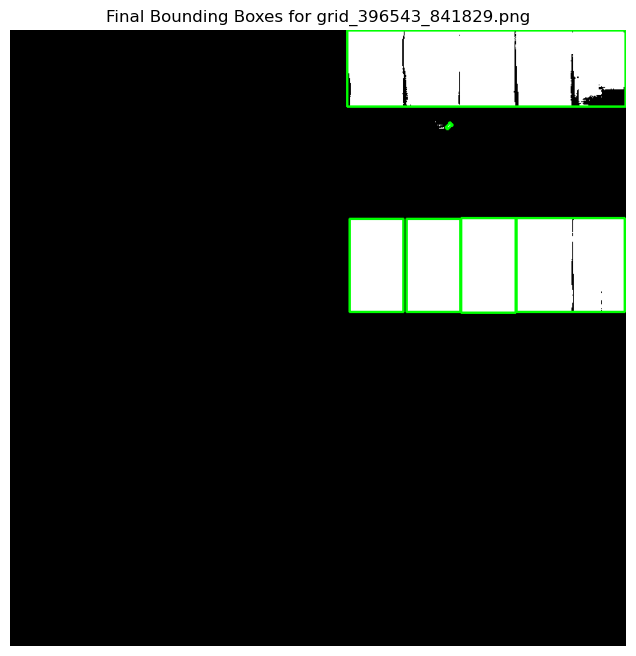

--------------------------------------------------
Processed grid_396549_841808.png → Found 2 shapes
  Shortest side lengths (cm): [419.07, 427.0]
  Longest side lengths  (cm): [439.82, 476.0]


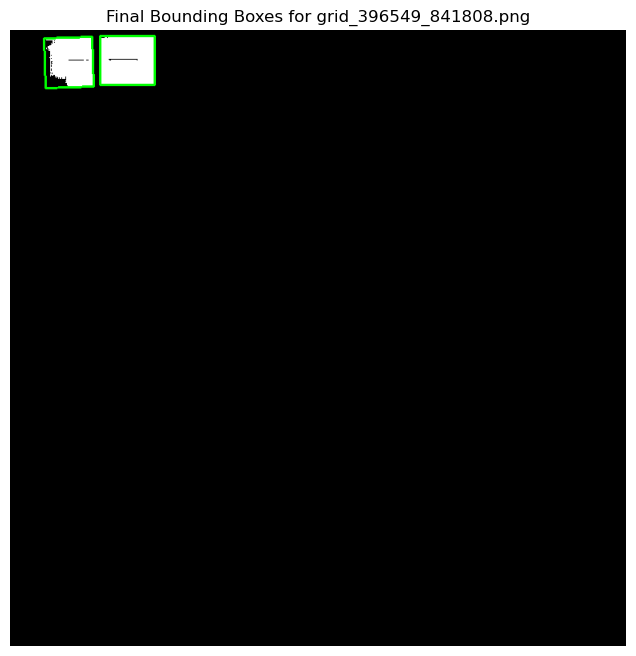

--------------------------------------------------
Processed grid_396555_841784.png → Found 4 shapes
  Shortest side lengths (cm): [196.0, 203.0, 196.0, 203.0]
  Longest side lengths  (cm): [224.0, 224.0, 217.0, 217.0]


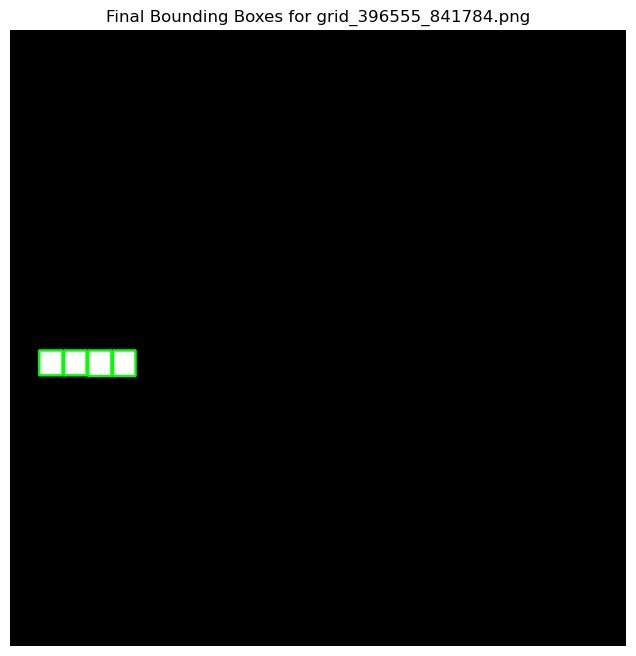

--------------------------------------------------
Processed grid_396573_841814.png → Found 1 shapes
  Shortest side lengths (cm): [273.67]
  Longest side lengths  (cm): [469.9]


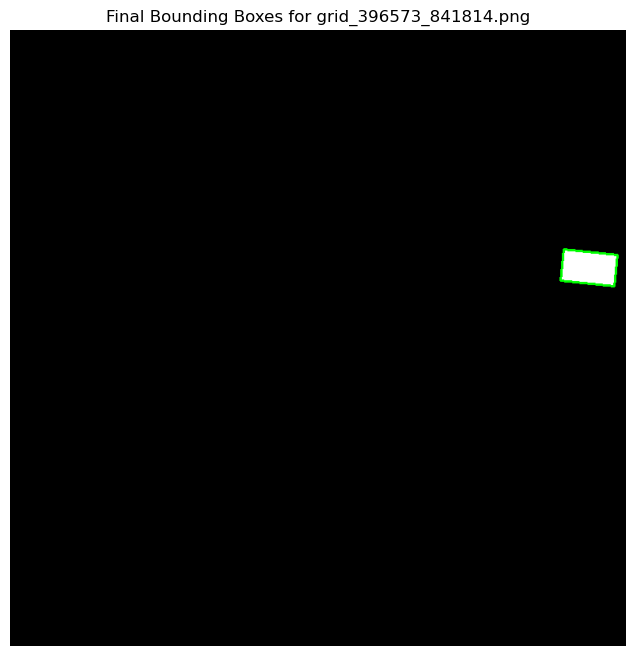

--------------------------------------------------
Processed grid_396585_841781.png → Found 1 shapes
  Shortest side lengths (cm): [292.04]
  Longest side lengths  (cm): [410.83]


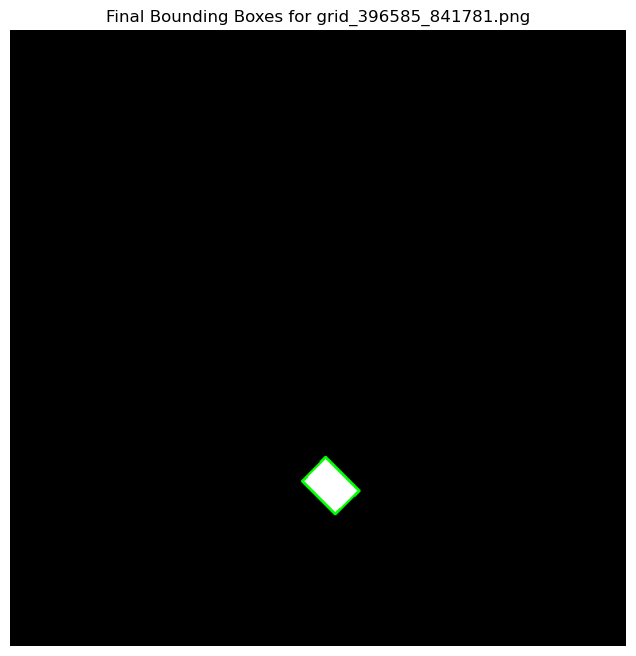


✅ All masks have been processed.


In [12]:
# === Configuration ===
# Directory where your final, human-verified masks are stored
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
MASK_DIR = config['dirs']['final_masks']
PIXEL_TO_CM = config['processing']['pixel_to_cm']

# --- Main Script Logic ---

# Get the list of all mask files to process
try:
    mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith(".png")])
    if not mask_files:
        print(f"Warning: No mask files found in {MASK_DIR}. Please run the SAM masking cell first.")
    else:
        print(f"✅ Found {len(mask_files)} masks to process in {MASK_DIR}")
except FileNotFoundError:
    print(f"Error: The directory '{MASK_DIR}' was not found. Please ensure the path is correct.")
    mask_files = []

# Loop through each mask file, find contours, calculate dimensions, and draw bounding boxes.
for fname in mask_files:
    mask_path = os.path.join(MASK_DIR, fname)
    mask = np.array(Image.open(mask_path).convert("L"))

    # Binarize mask to ensure it's a simple black and white image
    binary_mask = (mask > 0).astype(np.uint8)

    # Find contours of all distinct white shapes in the mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Lists to store the dimensions for all shapes found in this image
    shortest_lengths_cm = []
    longest_lengths_cm = []

    # Create a color image from the grayscale mask to draw green boxes on
    vis_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    # Process each contour found
    for cnt in contours:
        # Skip small contours that are likely noise
        if cv2.contourArea(cnt) < 10:
            continue

        # Get the minimum area rotated rectangle
        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1] # width and height in pixels

        if w == 0 or h == 0:
            continue

        # Determine shortest and longest sides in pixels
        shortest_px = min(w, h)
        longest_px = max(w, h)

        # Convert pixel dimensions to centimeters
        shortest_cm = shortest_px * PIXEL_TO_CM
        longest_cm = longest_px * PIXEL_TO_CM

        # Append the calculated dimensions to our lists
        shortest_lengths_cm.append(round(shortest_cm, 2))
        longest_lengths_cm.append(round(longest_cm, 2))

        # Get the 4 corner points and draw the rectangle for visualization
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        cv2.drawContours(vis_img, [box], 0, (0, 255, 0), 2)

    # --- Print and display the results for the current file ---
    print("-" * 50)
    print(f"Processed {fname} → Found {len(shortest_lengths_cm)} shapes")
    print(f"  Shortest side lengths (cm): {shortest_lengths_cm}")
    print(f"  Longest side lengths  (cm): {longest_lengths_cm}")

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Final Bounding Boxes for {fname}")
    plt.axis("off")
    plt.show()

if mask_files:
    print("\n✅ All masks have been processed.")

# Creating FULL PNG MASK

In [11]:
try:
    with open('config.yaml', 'r') as f:
        config = yaml.safe_load(f)
except FileNotFoundError:
    print("Error: config.yaml not found. Please ensure it is in the same directory.")
    # Exit or raise an exception if the config is essential
    exit()

# --- 2. Assign Variables from Config ---
# This script uses the final masks from the 'accepted' HITL stage
MASK_DIR = config['dirs']['final_masks'] 
OUTPUTS_DIR = config['dirs']['outputs']

# Construct full paths for input/output files
GRID_MAP_PATH = os.path.join(OUTPUTS_DIR, config['files']['grid_tile_map_json'])
FINAL_MASK_PNG = os.path.join(OUTPUTS_DIR, config['files']['final_stitched_mask_png'])

# Processing settings from config
TILE_SIZE = config['processing']['tile_size']
GRID_SIZE = config['processing']['grid_size']
GRID_OUTPUT_SIZE = TILE_SIZE * GRID_SIZE

# --- Main Script Logic ---

# Ensure the final output directory exists
os.makedirs(OUTPUTS_DIR, exist_ok=True)

try:
    # === Load grid map to get the spatial order of the stitched grids
    print(f"Loading grid map from: {GRID_MAP_PATH}")
    with open(GRID_MAP_PATH, "r") as f:
        grid_map = json.load(f)
except FileNotFoundError:
    print(f"Error: Grid map not found at {GRID_MAP_PATH}. Please run the stitching cell first.")
else:
    # === Load all individual mask images into memory
    indexed_images = []
    print(f"Loading individual masks from: {MASK_DIR}")
    for grid_index in tqdm(grid_map.keys(), desc="🔍 Loading masks"):
        parts = grid_index.split("_")
        x, y = int(parts[1]), int(parts[2])
        mask_path = os.path.join(MASK_DIR, f"{grid_index}.png")

        if not os.path.exists(mask_path):
            # This is expected for grids that were rejected in the HITL step
            continue

        img = Image.open(mask_path).convert("L")
        indexed_images.append(((x, y), np.array(img)))

    if not indexed_images:
        print(f"Error: No mask files found in {MASK_DIR}. Please run the SAM masking step.")
    else:
        # === Build the spatial layout of the grids
        grid_dict = defaultdict(dict)
        for (x, y), img in indexed_images:
            grid_dict[y][x] = img

        sorted_rows = sorted(grid_dict.keys())
        x_coords_all = sorted(set(x for y in sorted_rows for x in grid_dict[y]))
        num_cols = len(x_coords_all)
        num_rows = len(sorted_rows)

        # === Allocate the final, large image canvas (grayscale)
        final_image = np.zeros((num_rows * GRID_OUTPUT_SIZE, num_cols * GRID_OUTPUT_SIZE), dtype=np.uint8)

        print("Stitching masks row-by-row...")
        for row_idx, y in enumerate(sorted_rows):
            x_in_row = sorted(grid_dict[y].keys())
            for col_idx, x in enumerate(x_in_row):
                img = grid_dict[y][x]
                final_image[row_idx * GRID_OUTPUT_SIZE:(row_idx + 1) * GRID_OUTPUT_SIZE,
                            col_idx * GRID_OUTPUT_SIZE:(col_idx + 1) * GRID_OUTPUT_SIZE] = img
        
        # === Save the final stitched mask
        Image.fromarray(final_image, mode="L").save(FINAL_MASK_PNG)
        print(f"✅ Final stitched binary mask PNG saved to: {FINAL_MASK_PNG}")

🔍 Loading masks: 100%|██████████| 1764/1764 [00:21<00:00, 83.63it/s] 


Stitching masks row-by-row (grayscale)...
Final stitched binary mask PNG saved: /scratch/ajain381/Cooling_tower/KT_Files/tempe_latest/tempe_latest_stitched_final_mask.png
